# Chapter 3 — Framework 3: Concordant-site LDA projection and all-site posterior assignment

This notebook follows the same narrative structure as Framework 2 so the analytical story can be read top to bottom while the reusable implementation details stay isolated in a dedicated Definition Corner.

The execution structure is:

```text
Inputs → Analysis parameters → Definition Corner → Process → Outputs → Visualization
```

The workflow loads the A4 concordance artifact together with the taxa and environmental matrices, trains concordant and benchmark LDA models, projects the concordant decision region onto PCA planes for both concordant sites and all 310 sites, and then organizes the posterior-based assignment tables into cluster-specific outputs.

# Inputs

Load site metadata, the taxa and environmental matrices, and the A4 concordance artifact that supplies the reference-site cluster labels and concordance margins used in the LDA workflow.

In [225]:
from pathlib import Path
import pandas as pd

# Repository paths
METADATA_DIR = Path("../data")
ARTIFACT_DIR = Path("../artifacts")
RESULTS_DIR = Path("../results")
FIGURE_DIR = Path("../figures")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load site sample information
site_info = pd.read_excel(METADATA_DIR / "Info.xlsx")
site_ids = site_info["Integrated Code"].reset_index(drop=True).rename("Integrated Code")

# Load the environmental variables matrix E and merge with site IDs
E = pd.read_excel(METADATA_DIR / "E.xlsx").reset_index(drop=True)
E_with_site_id = pd.concat([site_ids, E], axis=1)

# Load the A4 reference sites with cluster labels and descriptor margins
A4 = pd.read_excel(ARTIFACT_DIR / "A4_refsites_concordance_margins.xlsx").reset_index(drop=True)

print(f"Loaded environmental matrix E: {E_with_site_id.shape[0]} sites x {E_with_site_id.shape[1] - 1} environmental variables")
display(E_with_site_id.head())
print(f"Loaded A4 reference-site artifact: {A4.shape[0]} sites")
display(A4.head())

Loaded environmental matrix E: 310 sites x 6 environmental variables


,Integrated Code,LOI (%),Measured Depth (m),Temperature (oC),Water DO Bottom (mg/L),MPS (Phi),Velocity at bottom (m/sec)
0,DR-02,1.140000,5.9436,15.0,9.8,0.555556,0.37186
1,DR-03,0.780000,3.2004,15.5,10.6,0.566667,0.44179
2,DR-04,0.530000,1.2192,17.0,9.0,0.642857,0.08216
3,DR-06,4.173333,8.0772,16.0,9.3,2.238095,0.14675
4,DR-07,0.820000,2.1336,16.0,12.5,0.647059,0.18312


Loaded A4 reference-site artifact: 62 sites


,Integrated Code,Cluster Label,taxa sibling co-assign,taxa nonsibling co-assign,env sibling co-assign,env nonsibling co-assign,taxa margin,environmental margin
0,LSC-26,C1,0.975629,0.042084,0.759353,0.514311,0.933546,0.245042
1,LSC-53,C1,0.975883,0.034566,0.761832,0.520157,0.941317,0.241675
2,LSC-41,C1,0.849315,0.157135,0.733783,0.594445,0.692180,0.139338
3,LSC-42,C2,0.954079,0.026972,0.704866,0.572625,0.927107,0.132241
4,LSC-40,C2,0.954601,0.029337,0.716326,0.633412,0.925264,0.082915


## Analysis parameters

These parameters control the concordance-status split, the concordant and benchmark LDA feature sets, the posterior threshold used for decision boundaries and multi-membership assignment, and the PCA projection settings used later in the notebook.

In [ ]:
SITE_ID_COLUMN = "Integrated Code"
CLUSTER_LABEL_COLUMN = "Cluster Label"
TAXA_MARGIN_COLUMN = "taxa margin"
ENVIRONMENTAL_MARGIN_COLUMN = "environmental margin"
CONCORDANCE_STATUS_COLUMN = "concordance status"

# Alternative environmental features: "LOI (%)", "Measured Depth (m)", "Temperature (oC)", "Water DO Bottom (mg/L)", "MPS (Phi)", "Velocity  at bottom (m/sec)"
TRAINING_LDA_FEATURES = ["Measured Depth (m)", "Temperature (oC)", "Water DO Bottom (mg/L)"]

DECISION_BOUNDARY_POSTERIOR_PROBABILITY = 0.4
PCA_PADDING_FRACTION = 0.1
PCA_GRID_STEP = 0.05
PCA_GRID_POINTS = 41
ALL_SITE_FLIP_PC1 = True
ALL_SITE_FLIP_PC2 = True

STATUS_NAME_MAP = {
    (1, 1): "concordant_set",
    (0, 1): "taxa_conflicting_set",
    (1, 0): "env_conflicting_set",
    (0, 0): "over_conflicting_set",
}

print("Framework 3 parameter setting")
print(f"Selected concordant LDA features: {TRAINING_LDA_FEATURES}")
print(f"Decision-boundary posterior threshold: {DECISION_BOUNDARY_POSTERIOR_PROBABILITY}")
print(f"PCA padding fraction: {PCA_PADDING_FRACTION}")
print(f"PCA grid step: {PCA_GRID_STEP}")
print(f"All-site axis flips: PC1 = {ALL_SITE_FLIP_PC1}, PC2 = {ALL_SITE_FLIP_PC2}")

Framework 3 parameter setting
Selected concordant LDA features: ['Measured Depth (m)', 'Temperature (oC)', 'Water DO Bottom (mg/L)']
Decision-boundary posterior threshold: 0.7
PCA padding fraction: 0.1
PCA grid step: 0.05
All-site axis flips: PC1 = True, PC2 = True


# Definition Corner

The following cells define the reusable tools used by the visible workflow below. They can be collapsed during reading so the notebook narrative stays focused on the concordance split, LDA fitting, PCA projection, and posterior-based assignment outputs.

In [227]:
from dataclasses import dataclass

import numpy as np
import pandas as pd


def siteid_subset_selector(
    source_dataframe: pd.DataFrame,
    target_site_ids: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    """Return source rows whose site IDs appear in the target dataframe."""
    if id_col not in source_dataframe.columns:
        raise KeyError(f"The source dataframe must contain the identifier column {id_col!r}.")

    if not isinstance(target_site_ids, pd.DataFrame):
        raise TypeError("target_site_ids must be a dataframe containing the site IDs to select.")

    if id_col in target_site_ids.columns:
        selected_ids = target_site_ids[id_col]
    elif target_site_ids.shape[1] == 1:
        selected_ids = target_site_ids.iloc[:, 0]
    else:
        raise KeyError(f"The target dataframe must contain {id_col!r} or exactly one column.")

    selected_ids = pd.Index(pd.unique(selected_ids.dropna().astype(str)))
    if selected_ids.empty:
        raise ValueError("The target site-ID dataframe does not contain any valid site IDs.")

    source_ids = source_dataframe[id_col].astype(str)
    if source_ids.duplicated().any():
        duplicated_ids = source_ids.loc[source_ids.duplicated()].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the source dataframe: {duplicated_ids}")

    available_ids = set(source_ids)
    missing_ids = [site_id for site_id in selected_ids if site_id not in available_ids]
    if missing_ids:
        raise ValueError(f"Target site IDs missing from the source dataframe: {missing_ids[:10]}")

    subset = source_dataframe.loc[source_ids.isin(selected_ids)].copy()
    subset[id_col] = subset[id_col].astype(str)
    subset["_selection_order"] = pd.Categorical(
        subset[id_col],
        categories=selected_ids.tolist(),
        ordered=True,
    )
    subset = subset.sort_values("_selection_order").drop(columns="_selection_order").reset_index(drop=True)
    return subset


def zscore_standardize_matrix(
    descriptor_matrix: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    """Z-score standardize descriptor columns, dropping any descriptor that contains missing values."""
    if id_col not in descriptor_matrix.columns:
        raise KeyError(f"The dataframe must contain the identifier column {id_col!r}.")

    value_columns = [column for column in descriptor_matrix.columns if column != id_col]
    if not value_columns:
        raise ValueError("The descriptor matrix must contain at least one descriptor column.")

    numeric_values = descriptor_matrix[value_columns].apply(pd.to_numeric, errors="coerce")
    complete_columns = numeric_values.columns[~numeric_values.isna().any()].tolist()
    if not complete_columns:
        raise ValueError("No complete descriptor columns remain after dropping columns with missing values.")

    numeric_values = numeric_values[complete_columns]
    numeric_values.index = descriptor_matrix[id_col].astype(str)
    numeric_values.index.name = id_col

    means = numeric_values.mean(axis=0)
    stds = numeric_values.std(axis=0, ddof=0).replace(0.0, np.nan)
    standardized_values = numeric_values.sub(means, axis=1).div(stds, axis=1).fillna(0.0)

    standardized_matrix = pd.concat(
        [descriptor_matrix[[id_col]].reset_index(drop=True), standardized_values.reset_index(drop=True)],
        axis=1,
    )
    return standardized_matrix


def concordance_status_filter(
    a4_artifact: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    taxa_margin_col: str = TAXA_MARGIN_COLUMN,
    environmental_margin_col: str = ENVIRONMENTAL_MARGIN_COLUMN,
    status_col: str = CONCORDANCE_STATUS_COLUMN,
    ) -> pd.DataFrame:
    """Assign each A4 site to one of four concordance-status combinations."""
    required_columns = {id_col, taxa_margin_col, environmental_margin_col}
    missing_columns = required_columns.difference(a4_artifact.columns)
    if missing_columns:
        raise KeyError(f"The A4 artifact is missing required columns: {sorted(missing_columns)}")

    status_table = a4_artifact[[id_col, taxa_margin_col, environmental_margin_col]].copy()
    status_table[id_col] = status_table[id_col].astype(str)
    if status_table[id_col].duplicated().any():
        duplicated_ids = status_table.loc[status_table[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the A4 artifact: {duplicated_ids}")

    status_table[taxa_margin_col] = pd.to_numeric(status_table[taxa_margin_col], errors="coerce")
    status_table[environmental_margin_col] = pd.to_numeric(status_table[environmental_margin_col], errors="coerce")
    incomplete_rows = status_table.loc[
        status_table[[taxa_margin_col, environmental_margin_col]].isna().any(axis=1),
        id_col,
    ].tolist()
    if incomplete_rows:
        raise ValueError(f"The A4 artifact contains incomplete margin values for: {incomplete_rows[:10]}")

    taxa_sign = (status_table[taxa_margin_col] >= 0.0).astype(int)
    environmental_sign = (status_table[environmental_margin_col] >= 0.0).astype(int)
    status_table[status_col] = list(zip(taxa_sign, environmental_sign))
    return status_table[[id_col, status_col]].copy()


def standardize_selected_features_against_reference(
    feature_matrix: pd.DataFrame,
    reference_matrix: pd.DataFrame,
    feature_names: list[str] | tuple[str, ...] | pd.Index,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    """Standardize selected features using the means and standard deviations from a reference matrix."""
    if id_col not in feature_matrix.columns or id_col not in reference_matrix.columns:
        raise KeyError(f"Both matrices must contain the identifier column {id_col!r}.")

    selected_features = [str(feature_name) for feature_name in feature_names]
    if not selected_features:
        raise ValueError("feature_names must contain at least one descriptor column.")

    missing_input_features = [feature_name for feature_name in selected_features if feature_name not in feature_matrix.columns]
    missing_reference_features = [feature_name for feature_name in selected_features if feature_name not in reference_matrix.columns]
    if missing_input_features or missing_reference_features:
        raise KeyError("Selected features must exist in both the feature matrix and the reference matrix.")

    input_values = feature_matrix[selected_features].apply(pd.to_numeric, errors="coerce")
    reference_values = reference_matrix[selected_features].apply(pd.to_numeric, errors="coerce")

    incomplete_input_features = input_values.columns[input_values.isna().any()].tolist()
    incomplete_reference_features = reference_values.columns[reference_values.isna().any()].tolist()
    if incomplete_input_features or incomplete_reference_features:
        raise ValueError(
            "Selected features used for prediction must be complete in both the input and reference matrices."
        )

    means = reference_values.mean(axis=0)
    stds = reference_values.std(axis=0, ddof=0).replace(0.0, np.nan)
    standardized_values = input_values.sub(means, axis=1).div(stds, axis=1).fillna(0.0)

    standardized_matrix = pd.concat(
        [feature_matrix[[id_col]].reset_index(drop=True), standardized_values.reset_index(drop=True)],
        axis=1,
    )
    return standardized_matrix


def _build_status_subsets(
    concordance_status_table: pd.DataFrame,
    status_name_map: dict[tuple[int, int], str],
    id_col: str = SITE_ID_COLUMN,
    status_col: str = CONCORDANCE_STATUS_COLUMN,
    ) -> dict[str, pd.DataFrame]:
    """Return the named concordance-status subsets described by STATUS_NAME_MAP."""
    status_subsets: dict[str, pd.DataFrame] = {}
    for status_code, subset_name in status_name_map.items():
        subset = concordance_status_table.loc[
            concordance_status_table[status_col] == status_code,
            [id_col, status_col],
        ].reset_index(drop=True)
        if not subset.empty:
            status_subsets[subset_name] = subset
    return status_subsets


def _get_status_subset(
    status_subsets: dict[str, pd.DataFrame],
    subset_name: str,
    id_col: str = SITE_ID_COLUMN,
    status_col: str = CONCORDANCE_STATUS_COLUMN,
    ) -> pd.DataFrame:
    """Return one named status subset or an empty table with the expected columns."""
    return status_subsets.get(
        subset_name,
        pd.DataFrame(columns=[id_col, status_col]),
    ).copy()


def _build_nonconcordant_set(
    concordance_status_table: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    status_col: str = CONCORDANCE_STATUS_COLUMN,
    ) -> pd.DataFrame:
    """Return all non-concordant sites from the concordance-status table."""
    return concordance_status_table.loc[
        concordance_status_table[status_col] != (1, 1),
        [id_col, status_col],
    ].reset_index(drop=True)

In [228]:
@dataclass
class FittedLinearDiscriminantClassifier:
    feature_names: list[str]
    class_labels: list[str]
    class_priors: pd.Series
    class_means: pd.DataFrame
    pooled_covariance: pd.DataFrame
    pooled_precision: np.ndarray

    def _prepare_feature_matrix(
        self,
        feature_matrix: pd.DataFrame,
        id_col: str = SITE_ID_COLUMN,
        ) -> pd.DataFrame:
        working_matrix = feature_matrix.copy()

        missing_features = [feature_name for feature_name in self.feature_names if feature_name not in working_matrix.columns]
        if missing_features:
            raise KeyError(f"Feature matrix is missing required LDA features: {missing_features}")

        numeric_values = working_matrix[self.feature_names].apply(pd.to_numeric, errors="coerce")
        if numeric_values.isna().any().any():
            incomplete_features = numeric_values.columns[numeric_values.isna().any()].tolist()
            raise ValueError(f"Feature matrix contains missing or non-numeric values in: {incomplete_features}")

        if id_col in working_matrix.columns:
            numeric_values.index = working_matrix[id_col].astype(str)
            numeric_values.index.name = id_col

        return numeric_values

    def decision_function(
        self,
        feature_matrix: pd.DataFrame,
        id_col: str = SITE_ID_COLUMN,
        ) -> pd.DataFrame:
        predictors = self._prepare_feature_matrix(feature_matrix, id_col=id_col)
        predictor_array = predictors.to_numpy(dtype=float)

        score_columns: dict[str, np.ndarray] = {}
        for class_label in self.class_labels:
            mean_vector = self.class_means.loc[class_label, self.feature_names].to_numpy(dtype=float)
            offset = -0.5 * mean_vector.T @ self.pooled_precision @ mean_vector
            offset += np.log(float(self.class_priors.loc[class_label]))
            score_columns[class_label] = predictor_array @ self.pooled_precision @ mean_vector + offset

        return pd.DataFrame(score_columns, index=predictors.index)

    def predict(
        self,
        feature_matrix: pd.DataFrame,
        id_col: str = SITE_ID_COLUMN,
        ) -> pd.Series:
        scores = self.decision_function(feature_matrix, id_col=id_col)
        return scores.idxmax(axis=1).rename("predicted cluster label")


def train_linear_discriminant_analysis(
    environmental_features: pd.DataFrame,
    cluster_labels: pd.DataFrame,
    feature_names: list[str] | tuple[str, ...] | pd.Index | None = None,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> FittedLinearDiscriminantClassifier:
    """Fit a pooled-covariance LDA classifier on aligned environmental features and cluster labels."""
    required_feature_columns = {id_col}
    required_label_columns = {id_col, cluster_col}
    if not required_feature_columns.issubset(environmental_features.columns):
        raise KeyError(f"The environmental feature matrix must contain {sorted(required_feature_columns)}")
    if not required_label_columns.issubset(cluster_labels.columns):
        raise KeyError(f"The label dataframe must contain {sorted(required_label_columns)}")

    if feature_names is None:
        selected_features = [column for column in environmental_features.columns if column != id_col]
    else:
        selected_features = [str(feature_name) for feature_name in feature_names]

    if not selected_features:
        raise ValueError("At least one environmental feature must be supplied to the LDA trainer.")

    missing_features = [feature_name for feature_name in selected_features if feature_name not in environmental_features.columns]
    if missing_features:
        raise KeyError(f"Requested LDA features not found in the environmental feature matrix: {missing_features}")

    feature_frame = environmental_features[[id_col] + selected_features].copy()
    feature_frame[id_col] = feature_frame[id_col].astype(str)
    feature_frame[selected_features] = feature_frame[selected_features].apply(pd.to_numeric, errors="coerce")
    if feature_frame[selected_features].isna().any().any():
        incomplete_features = feature_frame[selected_features].columns[feature_frame[selected_features].isna().any()].tolist()
        raise ValueError(f"Training features contain missing or non-numeric values in: {incomplete_features}")

    label_frame = cluster_labels[[id_col, cluster_col]].copy()
    label_frame[id_col] = label_frame[id_col].astype(str)
    label_frame[cluster_col] = label_frame[cluster_col].astype(str)
    if label_frame[id_col].duplicated().any():
        duplicated_ids = label_frame.loc[label_frame[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the training labels: {duplicated_ids}")

    training_frame = label_frame.merge(feature_frame, on=id_col, how="inner", validate="one_to_one")
    if training_frame.empty:
        raise ValueError("No shared site IDs were found between the environmental features and cluster labels.")

    missing_training_ids = [site_id for site_id in label_frame[id_col] if site_id not in set(training_frame[id_col])]
    if missing_training_ids:
        raise ValueError(f"Training labels missing from the feature matrix: {missing_training_ids[:10]}")

    class_counts = training_frame[cluster_col].value_counts().sort_index()
    if class_counts.shape[0] < 2:
        raise ValueError("LDA training requires at least two unique cluster labels.")

    pooled_divisor = int(training_frame.shape[0] - class_counts.shape[0])
    if pooled_divisor <= 0:
        raise ValueError("LDA training requires more training sites than unique cluster labels.")

    class_means = training_frame.groupby(cluster_col, sort=True)[selected_features].mean()
    class_priors = class_counts / class_counts.sum()

    pooled_scatter = np.zeros((len(selected_features), len(selected_features)), dtype=float)
    for class_label, class_subset in training_frame.groupby(cluster_col, sort=True):
        centered_values = class_subset[selected_features].to_numpy(dtype=float) - class_means.loc[class_label].to_numpy(dtype=float)
        pooled_scatter += centered_values.T @ centered_values

    pooled_covariance_array = pooled_scatter / pooled_divisor
    pooled_covariance = pd.DataFrame(
        pooled_covariance_array,
        index=selected_features,
        columns=selected_features,
    )
    pooled_precision = np.linalg.pinv(pooled_covariance_array)

    return FittedLinearDiscriminantClassifier(
        feature_names=selected_features,
        class_labels=class_means.index.astype(str).tolist(),
        class_priors=class_priors,
        class_means=class_means,
        pooled_covariance=pooled_covariance,
        pooled_precision=pooled_precision,
    )


def build_confusion_matrix(
    label_dataframe: pd.DataFrame,
    predicted_labels: pd.Series,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    predicted_col: str = "predicted cluster label",
    ) -> pd.DataFrame:
    """Return a confusion matrix between observed cluster labels and predicted cluster labels."""
    observed_labels = label_dataframe[[id_col, cluster_col]].copy()
    observed_labels[id_col] = observed_labels[id_col].astype(str)
    observed_labels[cluster_col] = observed_labels[cluster_col].astype(str)

    predicted_frame = predicted_labels.rename(predicted_col).rename_axis(id_col).reset_index()
    predicted_frame[id_col] = predicted_frame[id_col].astype(str)
    predicted_frame[predicted_col] = predicted_frame[predicted_col].astype(str)

    evaluation_table = observed_labels.merge(
        predicted_frame,
        on=id_col,
        how="inner",
        validate="one_to_one",
    )
    if evaluation_table.empty:
        raise ValueError("No shared site IDs were found between the observed labels and predictions.")

    label_order = sorted(
        pd.unique(
            pd.concat(
                [evaluation_table[cluster_col], evaluation_table[predicted_col]],
                ignore_index=True,
            )
        ).astype(str).tolist()
    )
    confusion_matrix = pd.crosstab(
        evaluation_table[cluster_col],
        evaluation_table[predicted_col],
        rownames=["observed label"],
        colnames=["predicted label"],
        dropna=False,
    )
    confusion_matrix = confusion_matrix.reindex(index=label_order, columns=label_order, fill_value=0)
    confusion_matrix.index.name = "observed label"
    confusion_matrix.columns.name = "predicted label"
    return confusion_matrix

In [229]:
def _construct_complete_training_set(
    environmental_features: pd.DataFrame,
    cluster_labels: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> pd.DataFrame:
    """Merge one feature table and one label table into a single complete training set."""
    required_feature_columns = {id_col}
    required_label_columns = {id_col, cluster_col}
    if not required_feature_columns.issubset(environmental_features.columns):
        raise KeyError(f"The feature table must contain {sorted(required_feature_columns)}")
    if not required_label_columns.issubset(cluster_labels.columns):
        raise KeyError(f"The label table must contain {sorted(required_label_columns)}")

    feature_table = environmental_features.copy()
    label_table = cluster_labels[[id_col, cluster_col]].copy()
    feature_table[id_col] = feature_table[id_col].astype(str)
    label_table[id_col] = label_table[id_col].astype(str)
    label_table[cluster_col] = label_table[cluster_col].astype(str)

    complete_set = label_table.merge(
        feature_table,
        on=id_col,
        how="inner",
        validate="one_to_one",
    )
    if complete_set.empty:
        raise ValueError("No shared site IDs were found between the features and labels.")

    ordered_columns = [id_col, cluster_col] + [
        column for column in complete_set.columns
        if column not in {id_col, cluster_col}
    ]
    return complete_set[ordered_columns].reset_index(drop=True)


def concordant_training_set_constructor(
    environmental_concordant_features: pd.DataFrame,
    concordant_cluster_labels: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> pd.DataFrame:
    """Construct the complete concordant training set used for the concordant-site LDA."""
    return _construct_complete_training_set(
        environmental_concordant_features,
        concordant_cluster_labels,
        id_col=id_col,
        cluster_col=cluster_col,
    )


def benchmark_training_set_constructor(
    benchmark_environmental_features: pd.DataFrame,
    benchmark_cluster_labels: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> pd.DataFrame:
    """Construct the complete benchmark training set used for the all-A4 base LDA."""
    return _construct_complete_training_set(
        benchmark_environmental_features,
        benchmark_cluster_labels,
        id_col=id_col,
        cluster_col=cluster_col,
    )


def diagnostic_set_constructor(
    feature_sets: dict[str, pd.DataFrame],
    label_sets: dict[str, pd.DataFrame],
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> dict[str, pd.DataFrame]:
    """Construct status-specific complete diagnostic sets with both features and labels."""
    if set(feature_sets) != set(label_sets):
        raise ValueError("feature_sets and label_sets must have the same status keys.")

    diagnostic_sets: dict[str, pd.DataFrame] = {}
    for status_name in feature_sets:
        diagnostic_sets[status_name] = _construct_complete_training_set(
            feature_sets[status_name],
            label_sets[status_name],
            id_col=id_col,
            cluster_col=cluster_col,
        )
    return diagnostic_sets


@dataclass
class StandardizedLDAPipeline:
    fitted_classifier: FittedLinearDiscriminantClassifier
    feature_names: list[str]
    reference_means: pd.Series
    reference_stds: pd.Series

    def _standardize_feature_matrix(
        self,
        feature_matrix: pd.DataFrame,
        id_col: str = SITE_ID_COLUMN,
        ) -> pd.DataFrame:
        if id_col not in feature_matrix.columns:
            raise KeyError(f"The feature matrix must contain the identifier column {id_col!r}.")

        missing_features = [feature_name for feature_name in self.feature_names if feature_name not in feature_matrix.columns]
        if missing_features:
            raise KeyError(f"The feature matrix is missing required LDA features: {missing_features}")

        numeric_values = feature_matrix[self.feature_names].apply(pd.to_numeric, errors="coerce")
        if numeric_values.isna().any().any():
            incomplete_features = numeric_values.columns[numeric_values.isna().any()].tolist()
            raise ValueError(f"The feature matrix contains missing or non-numeric values in: {incomplete_features}")

        standardized_values = numeric_values.sub(self.reference_means, axis=1).div(self.reference_stds, axis=1).fillna(0.0)
        standardized_matrix = pd.concat(
            [feature_matrix[[id_col]].reset_index(drop=True), standardized_values.reset_index(drop=True)],
            axis=1,
        )
        return standardized_matrix

    def predict(
        self,
        feature_matrix: pd.DataFrame,
        id_col: str = SITE_ID_COLUMN,
        ) -> pd.Series:
        standardized_matrix = self._standardize_feature_matrix(feature_matrix, id_col=id_col)
        return self.fitted_classifier.predict(standardized_matrix, id_col=id_col)


def fit_standardized_lda_pipeline(
    complete_training_set: pd.DataFrame,
    feature_names: list[str] | tuple[str, ...] | pd.Index,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> StandardizedLDAPipeline:
    """Fit an LDA model on raw features while storing the training standardization reference."""
    selected_features = [str(feature_name) for feature_name in feature_names]
    if not selected_features:
        raise ValueError("feature_names must contain at least one descriptor column.")

    missing_features = [feature_name for feature_name in selected_features if feature_name not in complete_training_set.columns]
    if missing_features:
        raise KeyError(f"The complete training set is missing requested LDA features: {missing_features}")

    feature_matrix = complete_training_set[[id_col] + selected_features].copy()
    label_matrix = complete_training_set[[id_col, cluster_col]].copy()

    reference_values = feature_matrix[selected_features].apply(pd.to_numeric, errors="coerce")
    if reference_values.isna().any().any():
        incomplete_features = reference_values.columns[reference_values.isna().any()].tolist()
        raise ValueError(f"The complete training set contains missing or non-numeric values in: {incomplete_features}")

    reference_means = reference_values.mean(axis=0)
    reference_stds = reference_values.std(axis=0, ddof=0).replace(0.0, np.nan)
    standardized_feature_matrix = pd.concat(
        [
            feature_matrix[[id_col]].reset_index(drop=True),
            reference_values.sub(reference_means, axis=1).div(reference_stds, axis=1).fillna(0.0).reset_index(drop=True),
        ],
        axis=1,
    )

    fitted_classifier = train_linear_discriminant_analysis(
        standardized_feature_matrix,
        label_matrix,
        feature_names=selected_features,
        id_col=id_col,
        cluster_col=cluster_col,
    )
    return StandardizedLDAPipeline(
        fitted_classifier=fitted_classifier,
        feature_names=selected_features,
        reference_means=reference_means,
        reference_stds=reference_stds,
    )

In [230]:
def _empty_prediction_series(name: str = "predicted cluster label") -> pd.Series:
    """Return an empty predicted-label series with the expected name."""
    return pd.Series(dtype=object, name=name)


def _empty_confusion_matrix() -> pd.DataFrame:
    """Return an empty confusion-matrix placeholder."""
    return pd.DataFrame()


def _evaluate_pipeline_on_feature_label_set(
    fitted_pipeline: StandardizedLDAPipeline,
    feature_table: pd.DataFrame,
    label_table: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> tuple[pd.Series, pd.DataFrame]:
    """Predict one labeled feature table and return both labels and confusion matrix."""
    if feature_table.empty or label_table.empty:
        return _empty_prediction_series(), _empty_confusion_matrix()

    predicted_labels = fitted_pipeline.predict(feature_table, id_col=id_col)
    confusion_matrix = build_confusion_matrix(
        label_table,
        predicted_labels,
        id_col=id_col,
        cluster_col=cluster_col,
    )
    return predicted_labels, confusion_matrix


def _evaluate_pipeline_on_complete_set(
    fitted_pipeline: StandardizedLDAPipeline,
    complete_set: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> tuple[pd.Series, pd.DataFrame]:
    """Predict one complete labeled dataset and return both labels and confusion matrix."""
    if complete_set.empty:
        return _empty_prediction_series(), _empty_confusion_matrix()

    feature_table = complete_set[[id_col] + fitted_pipeline.feature_names].copy()
    label_table = complete_set[[id_col, cluster_col]].copy()
    return _evaluate_pipeline_on_feature_label_set(
        fitted_pipeline,
        feature_table,
        label_table,
        id_col=id_col,
        cluster_col=cluster_col,
    )

In [231]:
def stratify_diagnostic_confusion_matrix(
    fitted_classifier: StandardizedLDAPipeline,
    diagnostic_sets: dict[str, pd.DataFrame],
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> pd.DataFrame:
    """Evaluate one fitted LDA across all status-specific complete sets and return side-by-side confusion-matrix blocks."""
    if not diagnostic_sets:
        raise ValueError("diagnostic_sets must contain at least one status-specific complete set.")

    label_order = pd.Index(
        pd.unique(
            pd.concat(
                [
                    pd.Series(fitted_classifier.fitted_classifier.class_labels, dtype=str),
                    pd.concat(
                        [diagnostic_sets[status_name][cluster_col].astype(str) for status_name in diagnostic_sets],
                        ignore_index=True,
                    ),
                ],
                ignore_index=True,
            )
        )
    ).tolist()

    formatted_label_lookup = {
        label: f"Cluster {label}" if not str(label).startswith("Cluster ") else str(label)
        for label in label_order
    }

    matrix_blocks: dict[str, pd.DataFrame] = {}
    for status_name, complete_set in diagnostic_sets.items():
        _, confusion_matrix = _evaluate_pipeline_on_complete_set(
            fitted_classifier,
            complete_set,
            id_col=id_col,
            cluster_col=cluster_col,
        )
        confusion_matrix = confusion_matrix.reindex(index=label_order, columns=label_order, fill_value=0)
        correct_predictions = int(np.trace(confusion_matrix.to_numpy(dtype=int)))
        sample_size = int(confusion_matrix.to_numpy(dtype=int).sum())
        accuracy_value = 0.0 if sample_size == 0 else 100.0 * correct_predictions / sample_size

        confusion_matrix = confusion_matrix.astype(object)
        confusion_matrix.index = [formatted_label_lookup[label] for label in confusion_matrix.index]
        confusion_matrix.columns = [formatted_label_lookup[label] for label in confusion_matrix.columns]

        accuracy_row = pd.DataFrame(
            [["" for _ in confusion_matrix.columns]],
            index=["Accuracy"],
            columns=confusion_matrix.columns,
        )
        if len(confusion_matrix.columns) > 0:
            accuracy_row.iloc[0, 0] = f"{accuracy_value:.0f}% (n = {sample_size})"

        matrix_blocks[status_name.replace("_", " ").title()] = pd.concat(
            [confusion_matrix, accuracy_row],
            axis=0,
        )

    stratified_table = pd.concat(matrix_blocks, axis=1)
    stratified_table.index.name = "True label"
    stratified_table.columns.names = ["Status", "Predicted label"]
    return stratified_table

In [232]:
def random_split_cross_validator(
    training_set: pd.DataFrame,
    classifier_type: str = "LDA",
    feature_names: list[str] | tuple[str, ...] | pd.Index | None = None,
    b: int = 1000,
    k_folds: int = 5,
    test_proportion: float = 0.2,
    id_col: str = SITE_ID_COLUMN,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    random_seed: int = 123,
    ) -> pd.DataFrame:
    """Run repeated stratified k-fold cross-validation and return a mean +/- SE confusion matrix.

    The function aggregates one full confusion matrix per repeat, then reports the
    elementwise mean count and its standard error across repeats. The mean is used
    instead of the median because each repeat covers the full training set once, so
    the mean remains on the original count scale and estimates the expected count
    under random partitioning.
    """
    if str(classifier_type).strip().upper() != "LDA":
        raise ValueError("random_split_cross_validator currently supports only classifier_type='LDA'.")
    if b <= 0:
        raise ValueError("b must be a positive integer.")
    if k_folds < 2:
        raise ValueError("k_folds must be at least 2.")
    if not np.isclose(float(test_proportion), 1.0 / float(k_folds)):
        raise ValueError("This repeated k-fold validator expects test_proportion to equal 1 / k_folds.")

    required_columns = {id_col, cluster_col}
    missing_columns = required_columns.difference(training_set.columns)
    if missing_columns:
        raise KeyError(f"The training set is missing required columns: {sorted(missing_columns)}")

    selected_features = [
        column for column in training_set.columns
        if column not in {id_col, cluster_col}
    ] if feature_names is None else [str(feature_name) for feature_name in feature_names]
    if not selected_features:
        raise ValueError("feature_names must contain at least one descriptor column.")

    missing_features = [feature_name for feature_name in selected_features if feature_name not in training_set.columns]
    if missing_features:
        raise KeyError(f"Requested cross-validation features not found in the training set: {missing_features}")

    complete_training_set = training_set[[id_col, cluster_col] + selected_features].copy()
    complete_training_set[id_col] = complete_training_set[id_col].astype(str)
    complete_training_set[cluster_col] = complete_training_set[cluster_col].astype(str)
    complete_training_set[selected_features] = complete_training_set[selected_features].apply(pd.to_numeric, errors="coerce")
    if complete_training_set[selected_features].isna().any().any():
        incomplete_features = complete_training_set[selected_features].columns[complete_training_set[selected_features].isna().any()].tolist()
        raise ValueError(f"Training set contains missing or non-numeric cross-validation features in: {incomplete_features}")

    class_counts = complete_training_set[cluster_col].value_counts().sort_index()
    if class_counts.shape[0] < 2:
        raise ValueError("Cross-validation requires at least two unique class labels.")
    if int(class_counts.min()) < int(k_folds):
        raise ValueError("Each class must contain at least k_folds sites for repeated stratified k-fold validation.")

    label_order = sorted(class_counts.index.astype(str).tolist())
    formatted_label_lookup = {
        label: f"Cluster {label}" if not str(label).startswith("Cluster ") else str(label)
        for label in label_order
    }

    rng = np.random.default_rng(random_seed)
    repeat_confusion_matrices: list[pd.DataFrame] = []
    repeat_accuracies: list[float] = []

    for _ in range(int(b)):
        fold_members: list[list[int]] = [[] for _ in range(int(k_folds))]
        for class_label, class_subset in complete_training_set.groupby(cluster_col, sort=True):
            permuted_indices = rng.permutation(class_subset.index.to_numpy(dtype=int))
            fold_splits = np.array_split(permuted_indices, int(k_folds))
            for fold_index, fold_split in enumerate(fold_splits):
                fold_members[fold_index].extend(fold_split.tolist())

        repeat_confusion_matrix = pd.DataFrame(0.0, index=label_order, columns=label_order)
        for fold_index in range(int(k_folds)):
            test_index = pd.Index(sorted(fold_members[fold_index]))
            train_index = complete_training_set.index.difference(test_index)
            train_fold = complete_training_set.loc[train_index].reset_index(drop=True)
            test_fold = complete_training_set.loc[test_index].reset_index(drop=True)

            fitted_pipeline = fit_standardized_lda_pipeline(
                train_fold,
                feature_names=selected_features,
                id_col=id_col,
                cluster_col=cluster_col,
                )
            predicted_labels = fitted_pipeline.predict(
                test_fold[[id_col] + selected_features],
                id_col=id_col,
                )
            fold_confusion_matrix = build_confusion_matrix(
                test_fold[[id_col, cluster_col]],
                predicted_labels,
                id_col=id_col,
                cluster_col=cluster_col,
                )
            fold_confusion_matrix = fold_confusion_matrix.reindex(index=label_order, columns=label_order, fill_value=0)
            repeat_confusion_matrix += fold_confusion_matrix.astype(float)

        repeat_confusion_matrices.append(repeat_confusion_matrix.copy())
        repeat_total = float(repeat_confusion_matrix.to_numpy(dtype=float).sum())
        repeat_accuracy = 0.0 if np.isclose(repeat_total, 0.0) else float(np.trace(repeat_confusion_matrix.to_numpy(dtype=float)) / repeat_total)
        repeat_accuracies.append(repeat_accuracy)

    matrix_stack = np.stack([matrix.to_numpy(dtype=float) for matrix in repeat_confusion_matrices], axis=0)
    mean_matrix = matrix_stack.mean(axis=0)
    if int(b) > 1:
        stderr_matrix = matrix_stack.std(axis=0, ddof=1) / np.sqrt(float(b))
        accuracy_stderr = float(np.std(repeat_accuracies, ddof=1) / np.sqrt(float(b)))
    else:
        stderr_matrix = np.zeros_like(mean_matrix, dtype=float)
        accuracy_stderr = 0.0
    mean_accuracy = float(np.mean(repeat_accuracies))

    formatted_matrix = pd.DataFrame(
        "",
        index=[formatted_label_lookup[label] for label in label_order] + ["Accuracy"],
        columns=[formatted_label_lookup[label] for label in label_order],
        dtype=object,
    )
    for row_index, row_label in enumerate(label_order):
        for column_index, column_label in enumerate(label_order):
            formatted_matrix.loc[formatted_label_lookup[row_label], formatted_label_lookup[column_label]] = (
                f"{mean_matrix[row_index, column_index]:.2f} +/- {stderr_matrix[row_index, column_index]:.2f}"
            )
    formatted_matrix.iloc[-1, 0] = f"{100.0 * mean_accuracy:.0f}% +/- {100.0 * accuracy_stderr:.0f}% (n = {complete_training_set.shape[0]})"
    formatted_matrix.index.name = "True label"
    formatted_matrix.columns.name = "Predicted label"
    return formatted_matrix

In [233]:
def predict_lda_posterior_probabilities(
    fitted_lda_model: StandardizedLDAPipeline,
    feature_matrix: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    """Return posterior class probabilities from the fitted custom LDA pipeline."""
    if id_col not in feature_matrix.columns:
        raise KeyError(f"The feature matrix must contain the identifier column {id_col!r}.")

    selected_features = [str(feature_name) for feature_name in fitted_lda_model.feature_names]
    missing_features = [feature_name for feature_name in selected_features if feature_name not in feature_matrix.columns]
    if missing_features:
        raise KeyError(f"The feature matrix is missing required LDA features: {missing_features}")

    numeric_values = feature_matrix[selected_features].apply(pd.to_numeric, errors="coerce")
    incomplete_features = numeric_values.columns[numeric_values.isna().any()].tolist()
    if incomplete_features:
        raise ValueError(f"The feature matrix contains missing or non-numeric values in: {incomplete_features}")

    standardized_feature_matrix = pd.concat(
        [
            feature_matrix[[id_col]].reset_index(drop=True),
            numeric_values.sub(fitted_lda_model.reference_means, axis=1)
            .div(fitted_lda_model.reference_stds, axis=1)
            .fillna(0.0)
            .reset_index(drop=True),
        ],
        axis=1,
    )
    decision_scores = fitted_lda_model.fitted_classifier.decision_function(
        standardized_feature_matrix,
        id_col=id_col,
    )
    shifted_scores = decision_scores.sub(decision_scores.max(axis=1), axis=0)
    posterior_probabilities = np.exp(shifted_scores)
    posterior_probabilities = posterior_probabilities.div(posterior_probabilities.sum(axis=1), axis=0)
    posterior_probabilities.index.name = id_col
    posterior_probabilities.columns.name = "cluster label"
    return posterior_probabilities


def _extract_site_id_values(
    site_ids: pd.DataFrame | pd.Series | list[str] | tuple[str, ...] | pd.Index,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.Index:
    if isinstance(site_ids, pd.DataFrame):
        if id_col in site_ids.columns:
            selected_ids = site_ids[id_col]
        elif site_ids.shape[1] == 1:
            selected_ids = site_ids.iloc[:, 0]
        else:
            raise KeyError(f"The site-ID input must contain {id_col!r} or exactly one column.")
    elif isinstance(site_ids, pd.Series):
        selected_ids = site_ids
    else:
        selected_ids = pd.Series(list(site_ids))

    selected_index = pd.Index(pd.unique(selected_ids.dropna().astype(str)))
    if selected_index.empty:
        raise ValueError("The site-ID input does not contain any valid site IDs.")
    return selected_index


def _resolve_waterbody_column(
    sample_info: pd.DataFrame,
    preferred_column: str = "Water body",
    ) -> str:
    if preferred_column in sample_info.columns:
        return preferred_column

    normalized_lookup = {
        str(column).strip().lower().replace("_", " "): column
        for column in sample_info.columns
    }
    for candidate in ["water body", "waterbody"]:
        if candidate in normalized_lookup:
            return str(normalized_lookup[candidate])

    raise KeyError(
        f"Could not find a waterbody column in sample_info. Available columns: {sample_info.columns.tolist()}"
    )


def _build_posterior_color_values(
    probability_frame: pd.DataFrame,
    class_labels: list[str],
    base_color_lookup: dict[str, tuple[float, float, float]],
    minimum_alpha: float = 0.2,
    ) -> tuple[np.ndarray, np.ndarray]:
    ordered_probability_frame = probability_frame.reindex(columns=class_labels)
    probability_array = ordered_probability_frame.to_numpy(dtype=float)
    base_color_array = np.vstack([np.asarray(base_color_lookup[class_label], dtype=float) for class_label in class_labels])

    mixed_rgb = probability_array @ base_color_array
    certainty = probability_array.max(axis=1)
    blended_rgb = (1.0 - certainty[:, None]) * 1.0 + certainty[:, None] * mixed_rgb
    alpha_values = minimum_alpha + (1.0 - minimum_alpha) * certainty
    rgba_values = np.column_stack([blended_rgb, alpha_values])
    return rgba_values, certainty


def _build_status_summary(
    status_subsets: dict[str, pd.DataFrame],
    status_name_map: dict[tuple[int, int], str],
    ) -> pd.DataFrame:
    """Return a concise table describing the concordance-status subsets present in A4."""
    return pd.DataFrame(
        [
            {
                "subset name": subset_name,
                "status code": status_code,
                "site count": int(status_subsets.get(subset_name, pd.DataFrame()).shape[0]),
            }
            for status_code, subset_name in status_name_map.items()
        ]
    )


def _build_training_summary(
    training_features: pd.DataFrame,
    training_labels: pd.DataFrame,
    retained_training_features: list[str],
    dropped_training_features: list[str],
    training_lda_features: list[str],
    env_conflicting_labels: pd.DataFrame,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    ) -> pd.DataFrame:
    """Return the key counts and feature selections used by the Framework 3 LDA workflow."""
    training_clusters = sorted(training_labels[cluster_col].astype(str).unique().tolist()) if not training_labels.empty else []
    return pd.DataFrame(
        {
            "Quantity": [
                "Concordant training sites",
                "Training label rows",
                "Retained standardized environmental features",
                "Dropped environmental features",
                "LDA feature selection",
                "Training clusters",
                "Environmental-conflicting evaluation sites",
            ],
            "Value": [
                int(training_features.shape[0]),
                int(training_labels.shape[0]),
                ", ".join(retained_training_features),
                ", ".join(dropped_training_features) if dropped_training_features else "None",
                ", ".join(training_lda_features),
                ", ".join(training_clusters),
                int(env_conflicting_labels.shape[0]),
            ],
        }
    )


def _build_cluster_count_table(
    label_table: pd.DataFrame,
    cluster_col: str = CLUSTER_LABEL_COLUMN,
    count_col: str = "site count",
    ) -> pd.DataFrame:
    """Return one cluster-count table for a label dataframe."""
    if label_table.empty:
        return pd.DataFrame(columns=[cluster_col, count_col])
    return (
        label_table[cluster_col]
        .astype(str)
        .value_counts()
        .sort_index()
        .rename_axis(cluster_col)
        .reset_index(name=count_col)
    )


def _build_diagnostic_component_summary(
    training_features: pd.DataFrame,
    conflicting_features: pd.DataFrame,
    training_labels: pd.DataFrame,
    conflicting_labels: pd.DataFrame,
    ) -> pd.DataFrame:
    """Return a shape summary for the feature and label tables used in diagnostics."""
    return pd.DataFrame(
        [
            {"dataset": "concordant environmental features", "rows": int(training_features.shape[0]), "columns": int(training_features.shape[1])},
            {"dataset": "conflicting environmental features", "rows": int(conflicting_features.shape[0]), "columns": int(conflicting_features.shape[1])},
            {"dataset": "concordant cluster labels", "rows": int(training_labels.shape[0]), "columns": int(training_labels.shape[1])},
            {"dataset": "conflicting cluster labels", "rows": int(conflicting_labels.shape[0]), "columns": int(conflicting_labels.shape[1])},
        ]
    )


def _build_projection_summary(
    projection_label: str,
    pca_projection,
    ) -> pd.DataFrame:
    """Return the shared projection-summary table for one PCA decision-region projection."""
    return pd.DataFrame(
        {
            "setting": [
                "Projected sites",
                "PCA applied",
                "Concordant LDA features",
                "Held constant PCs outside plane",
                "Grid shape",
                "Grid PC step",
                "Figure dpi",
                "Single-feature fallback",
            ],
            "value": [
                int(pca_projection.site_projection_table.shape[0]),
                pca_projection.used_pca,
                ", ".join(pca_projection.feature_names),
                ", ".join(pca_projection.held_pc_values.index.tolist()) if not pca_projection.held_pc_values.empty else "None",
                f"{pca_projection.grid_environmental_features['PC1'].nunique()} x {pca_projection.grid_environmental_features['PC2'].nunique()}",
                pca_projection.grid_environmental_features.attrs.get("grid_step", "Not set"),
                300,
                "PC1 is the centered standardized feature axis and PC2 is fixed at 0." if not pca_projection.used_pca else "Not used",
            ],
        }
    )


def _build_projection_output_tables(
    projection_label: str,
    pca_projection,
    ) -> dict[str, pd.DataFrame]:
    """Collect the named projection-support tables shown in the Outputs section."""
    held_pc_table = (
        pca_projection.held_pc_values.to_frame(name="held PC score")
        if not pca_projection.held_pc_values.empty
        else pd.DataFrame(columns=["held PC score"])
    )
    return {
        "summary": _build_projection_summary(projection_label, pca_projection),
        "explained variance ratio": pca_projection.explained_variance_ratio.to_frame(),
        "feature loading table": pca_projection.feature_loading_table.copy(),
        "held constant PC scores": held_pc_table,
        "site projection table": pca_projection.site_projection_table.copy(),
        "grid environmental features": pca_projection.grid_environmental_features.copy(),
    }


def assign_multi_membership_tables(
    site_projection_table: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    cluster_membership_col: str = "cluster memberships",
    posterior_probability_prefix: str = "posterior probability: ",
    ) -> dict[str, pd.DataFrame]:
    """Split one site-projection table into one membership table per cluster using only assigned sites."""
    required_columns = {id_col, cluster_membership_col}
    missing_columns = required_columns.difference(site_projection_table.columns)
    if missing_columns:
        raise KeyError(
            f"site_projection_table is missing required columns: {sorted(missing_columns)}"
        )

    posterior_columns = [
        str(column)
        for column in site_projection_table.columns
        if str(column).startswith(posterior_probability_prefix)
    ]
    if not posterior_columns:
        raise ValueError(
            "site_projection_table must contain posterior-probability columns for each cluster."
        )

    cluster_labels = [
        posterior_column.replace(posterior_probability_prefix, "", 1)
        for posterior_column in posterior_columns
    ]

    working_projection_table = site_projection_table.reset_index(drop=True).copy()
    normalized_memberships: list[tuple[int, ...]] = []
    for row_index, membership_value in enumerate(working_projection_table[cluster_membership_col].tolist()):
        if isinstance(membership_value, np.ndarray):
            membership_tuple = tuple(membership_value.tolist())
        elif isinstance(membership_value, (list, tuple, pd.Series)):
            membership_tuple = tuple(membership_value)
        else:
            raise TypeError(
                f"Row {row_index} in {cluster_membership_col!r} must contain a tuple-like value."
            )
        if len(membership_tuple) != len(cluster_labels):
            raise ValueError(
                "Each cluster-membership tuple must align with the posterior-probability columns."
            )
        normalized_memberships.append(tuple(int(member_value) for member_value in membership_tuple))

    membership_frame = pd.DataFrame(normalized_memberships, columns=cluster_labels)
    cluster_membership_tables: dict[str, pd.DataFrame] = {}
    for cluster_label, posterior_column in zip(cluster_labels, posterior_columns):
        cluster_member_mask = membership_frame[cluster_label].astype(int).eq(1)
        cluster_membership_tables[cluster_label] = pd.DataFrame(
            {
                id_col: working_projection_table.loc[cluster_member_mask, id_col].astype(str).to_numpy(),
                "cluster membership": [str(cluster_label)] * int(cluster_member_mask.sum()),
                "posterior probability": pd.to_numeric(
                    working_projection_table.loc[cluster_member_mask, posterior_column],
                    errors="coerce",
                ).to_numpy(dtype=float),
            }
        ).reset_index(drop=True)

    return cluster_membership_tables


def _build_membership_table_variable_name(
    membership_prefix: str,
    cluster_label: str,
    ) -> str:
    """Return a stable notebook variable name for one cluster-specific membership table."""
    cluster_variable_suffix = "".join(
        character if str(character).isalnum() else "_"
        for character in str(cluster_label)
    ).strip("_")
    return f"{membership_prefix}_cluster_{cluster_variable_suffix}_membership_table"


def _register_membership_tables(
    membership_tables: dict[str, pd.DataFrame],
    membership_prefix: str,
    namespace: dict[str, object],
    ) -> dict[str, str]:
    """Bind cluster-specific membership tables into the notebook namespace and return their variable lookup."""
    variable_lookup: dict[str, str] = {}
    for cluster_label, membership_table in membership_tables.items():
        variable_name = _build_membership_table_variable_name(membership_prefix, str(cluster_label))
        namespace[variable_name] = membership_table
        variable_lookup[str(cluster_label)] = variable_name
    return variable_lookup

In [234]:
def _build_overview_output_tables(
    status_summary: pd.DataFrame,
    training_summary: pd.DataFrame,
    training_cluster_count_table: pd.DataFrame,
    benchmark_cluster_count_table: pd.DataFrame,
    diagnostic_component_summary: pd.DataFrame,
    concordant_class_means_table: pd.DataFrame,
    benchmark_class_means_table: pd.DataFrame,
    ) -> dict[str, pd.DataFrame]:
    """Collect the high-level support tables shown before the case-specific outputs."""
    return {
        "Concordance-status subsets present in A4": status_summary,
        "Framework 3 LDA training summary": training_summary,
        "Concordant training labels by cluster": training_cluster_count_table,
        "Benchmark training labels by cluster": benchmark_cluster_count_table,
        "Status-derived feature and label datasets": diagnostic_component_summary,
        "Fitted concordant LDA class means": concordant_class_means_table,
        "Fitted benchmark LDA class means": benchmark_class_means_table,
    }

In [235]:
@dataclass
class PCADecisionRegionProjection:
    used_pca: bool
    feature_names: list[str]
    ordination_scores: pd.DataFrame
    explained_variance_ratio: pd.Series
    held_pc_values: pd.Series
    feature_loading_table: pd.DataFrame
    grid_environmental_features: pd.DataFrame
    site_projection_table: pd.DataFrame


def visualize_pca_decision_region(
    grid_environmental_features: pd.DataFrame,
    concordant_site_ids: pd.DataFrame | pd.Series | list[str] | tuple[str, ...] | pd.Index,
    sample_info: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    waterbody_col: str = "Water body",
    figure_size: tuple[float, float] = (10.0, 8.0),
    marker_size: float = 80.0,
    dpi: int = 300,
    max_major_grid_lines: int = 8,
    arrow_span_fraction: float = 0.18,
    ):
    """Visualize the PC1-PC2 decision surface, PCA feature directions, and concordant sites on the same plane."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    required_grid_columns = {"PC1", "PC2", "predicted cluster label", "predicted posterior probability"}
    missing_grid_columns = required_grid_columns.difference(grid_environmental_features.columns)
    if missing_grid_columns:
        raise KeyError(f"grid_environmental_features is missing required columns: {sorted(missing_grid_columns)}")

    posterior_probability_column_lookup = grid_environmental_features.attrs.get("posterior_probability_column_lookup", {})
    if not posterior_probability_column_lookup:
        posterior_columns = [
            column for column in grid_environmental_features.columns
            if str(column).startswith("posterior probability: ")
        ]
        posterior_probability_column_lookup = {
            str(column).replace("posterior probability: ", "", 1): str(column)
            for column in posterior_columns
        }
    if not posterior_probability_column_lookup:
        raise ValueError(
            "grid_environmental_features does not contain posterior-probability columns from the PCA decision-region projector."
        )

    feature_loading_table = grid_environmental_features.attrs.get("feature_loading_table")
    if not isinstance(feature_loading_table, pd.DataFrame):
        raise ValueError(
            "grid_environmental_features does not carry the environmental feature directions needed for the PCA plane visualization."
        )
    feature_loading_table = feature_loading_table.copy()
    if "PC1" not in feature_loading_table.columns:
        raise ValueError("feature_loading_table must contain a PC1 column.")
    if "PC2" not in feature_loading_table.columns:
        feature_loading_table["PC2"] = 0.0

    class_labels = [str(class_label) for class_label in posterior_probability_column_lookup]
    posterior_probability_table = pd.DataFrame(
        {
            class_label: grid_environmental_features[posterior_probability_column_lookup[class_label]].to_numpy(dtype=float)
            for class_label in class_labels
        }
    )

    site_projection_table = grid_environmental_features.attrs.get("site_projection_table")
    if not isinstance(site_projection_table, pd.DataFrame):
        raise ValueError(
            "grid_environmental_features does not carry the concordant-site PC scores needed for visualization."
        )

    selected_site_ids = _extract_site_id_values(concordant_site_ids, id_col=id_col)
    site_projection_table = site_projection_table.loc[
        site_projection_table[id_col].astype(str).isin(selected_site_ids)
    ].copy()
    if site_projection_table.empty:
        raise ValueError("None of the requested concordant site IDs were found in the projected concordant site table.")

    resolved_waterbody_column = _resolve_waterbody_column(sample_info, preferred_column=waterbody_col)
    sample_metadata = sample_info[[id_col, resolved_waterbody_column]].copy()
    sample_metadata[id_col] = sample_metadata[id_col].astype(str)
    sample_metadata = sample_metadata.drop_duplicates(subset=[id_col]).reset_index(drop=True)

    site_projection_table[id_col] = site_projection_table[id_col].astype(str)
    site_projection_table = site_projection_table.merge(
        sample_metadata,
        on=id_col,
        how="left",
        validate="one_to_one",
    )
    site_projection_table[resolved_waterbody_column] = site_projection_table[resolved_waterbody_column].fillna("Unknown")

    base_cmap = plt.get_cmap("tab10")
    base_color_lookup = {
        class_label: base_cmap(class_index % base_cmap.N)[:3]
        for class_index, class_label in enumerate(class_labels)
    }

    grid_rgba_values, _ = _build_posterior_color_values(
        posterior_probability_table,
        class_labels=class_labels,
        base_color_lookup=base_color_lookup,
        minimum_alpha=0.25,
    )
    grid_plot_table = grid_environmental_features[["PC1", "PC2", "predicted cluster label", "predicted posterior probability"]].copy()
    grid_plot_table[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]] = grid_rgba_values

    pc1_values = np.sort(grid_plot_table["PC1"].astype(float).unique())
    pc2_values = np.sort(grid_plot_table["PC2"].astype(float).unique())
    expected_grid_size = int(len(pc1_values) * len(pc2_values))
    if int(grid_plot_table.shape[0]) != expected_grid_size:
        raise ValueError("grid_environmental_features does not form a complete PC1-PC2 grid.")

    ordered_grid_plot_table = grid_plot_table.sort_values(["PC2", "PC1"]).reset_index(drop=True)
    rgba_image = ordered_grid_plot_table[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]].to_numpy(dtype=float).reshape(
        len(pc2_values),
        len(pc1_values),
        4,
    )

    pc1_step = float(np.median(np.diff(pc1_values))) if len(pc1_values) > 1 else 1.0
    pc2_step = float(np.median(np.diff(pc2_values))) if len(pc2_values) > 1 else 1.0
    image_extent = [
        float(pc1_values.min() - 0.5 * pc1_step),
        float(pc1_values.max() + 0.5 * pc1_step),
        float(pc2_values.min() - 0.5 * pc2_step),
        float(pc2_values.max() + 0.5 * pc2_step),
    ]

    site_probability_table = pd.DataFrame(
        {
            class_label: site_projection_table[posterior_probability_column_lookup[class_label]].to_numpy(dtype=float)
            for class_label in class_labels
        }
    )
    site_rgba_values, _ = _build_posterior_color_values(
        site_probability_table,
        class_labels=class_labels,
        base_color_lookup=base_color_lookup,
        minimum_alpha=0.55,
    )
    site_projection_table[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]] = site_rgba_values

    marker_candidates = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
    waterbody_values = site_projection_table[resolved_waterbody_column].astype(str).unique().tolist()
    marker_lookup = {
        waterbody: marker_candidates[index % len(marker_candidates)]
        for index, waterbody in enumerate(sorted(waterbody_values))
    }

    fig, ax = plt.subplots(figsize=figure_size, dpi=int(dpi))
    ax.imshow(
        rgba_image,
        origin="lower",
        extent=image_extent,
        aspect="auto",
        interpolation="nearest",
        zorder=0,
    )

    major_x_every = max(1, int(np.ceil(len(pc1_values) / max(int(max_major_grid_lines), 1))))
    major_y_every = max(1, int(np.ceil(len(pc2_values) / max(int(max_major_grid_lines), 1))))
    ax.set_xticks(pc1_values[::major_x_every])
    ax.set_yticks(pc2_values[::major_y_every])
    if len(pc1_values) > 1:
        ax.set_xticks(pc1_values, minor=True)
    if len(pc2_values) > 1:
        ax.set_yticks(pc2_values, minor=True)
    ax.grid(which="major", color="black", linewidth=0.45, alpha=0.25)
    ax.grid(which="minor", color="black", linewidth=0.12, alpha=0.12)
    ax.tick_params(which="minor", bottom=False, left=False)

    origin_pc1 = float(grid_environmental_features.attrs.get("pca_origin_pc1", 0.0))
    origin_pc2 = float(grid_environmental_features.attrs.get("pca_origin_pc2", 0.0))
    span_reference = max(
        float(image_extent[1] - image_extent[0]),
        float(image_extent[3] - image_extent[2]),
        1.0,
    )
    loading_vectors = feature_loading_table[["PC1", "PC2"]].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    loading_lengths = np.sqrt((loading_vectors ** 2).sum(axis=1))
    max_loading_length = float(loading_lengths.max()) if not loading_lengths.empty else 1.0
    if np.isclose(max_loading_length, 0.0):
        max_loading_length = 1.0
    arrow_scale = float(arrow_span_fraction) * span_reference / max_loading_length

    ax.axhline(origin_pc2, color="black", linewidth=0.6, alpha=0.25, zorder=1)
    ax.axvline(origin_pc1, color="black", linewidth=0.6, alpha=0.25, zorder=1)
    for feature_name, loading_row in loading_vectors.iterrows():
        dx = float(loading_row["PC1"]) * arrow_scale
        dy = float(loading_row["PC2"]) * arrow_scale
        ax.annotate(
            "",
            xy=(origin_pc1 + dx, origin_pc2 + dy),
            xytext=(origin_pc1, origin_pc2),
            arrowprops={"arrowstyle": "-|>", "linewidth": 1.2, "color": "black", "shrinkA": 0.0, "shrinkB": 0.0},
            zorder=4,
        )
        x_offset = 0.02 * span_reference if np.isclose(dx, 0.0) else 0.02 * span_reference * np.sign(dx)
        y_offset = 0.02 * span_reference if np.isclose(dy, 0.0) else 0.02 * span_reference * np.sign(dy)
        ax.text(
            origin_pc1 + 1.06 * dx + x_offset,
            origin_pc2 + 1.06 * dy + y_offset,
            str(feature_name),
            fontsize=9,
            ha="center",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 1.0},
            zorder=5,
        )

    for waterbody_value in sorted(waterbody_values):
        waterbody_subset = site_projection_table.loc[
            site_projection_table[resolved_waterbody_column].astype(str) == str(waterbody_value)
        ].copy()
        if waterbody_subset.empty:
            continue
        point_colors = waterbody_subset[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]].to_numpy(dtype=float)
        ax.scatter(
            waterbody_subset["PC1"],
            waterbody_subset["PC2"],
            c=point_colors,
            marker=marker_lookup[str(waterbody_value)],
            s=float(marker_size),
            edgecolors="black",
            linewidths=0.7,
            zorder=6,
        )

    cluster_handles = [
        Line2D(
            [0],
            [0],
            marker="s",
            linestyle="",
            markerfacecolor=base_color_lookup[class_label],
            markeredgecolor="none",
            markersize=10,
            label=f"Cluster {class_label}",
        )
        for class_label in class_labels
    ]
    waterbody_handles = [
        Line2D(
            [0],
            [0],
            marker=marker_lookup[waterbody_value],
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=9,
            label=str(waterbody_value),
        )
        for waterbody_value in sorted(waterbody_values)
    ]

    cluster_legend = ax.legend(handles=cluster_handles, title="Cluster base color", loc="upper right")
    ax.add_artist(cluster_legend)
    ax.legend(handles=waterbody_handles, title="Water body", loc="lower right")

    ax.set_xlabel("PC1 score")
    ax.set_ylabel("PC2 score")
    ax.set_title("Concordant LDA decision region projected onto the PC1-PC2 plane")
    ax.text(
        0.01,
        0.01,
        "Cell color mixes cluster posteriors; stronger posterior support yields more saturated color.",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8},
    )
    fig.tight_layout()
    plt.close(fig)

    return fig


class PCADecisionRegionProjector:
    """Project an LDA decision region onto the concordant-set PC1-PC2 ordination plane."""

    def __init__(
        self,
        concordant_environmental_features: pd.DataFrame,
        fitted_lda_model: StandardizedLDAPipeline,
        id_col: str = SITE_ID_COLUMN,
        ) -> None:
        if id_col not in concordant_environmental_features.columns:
            raise KeyError(f"The concordant environmental features must contain {id_col!r}.")

        self.id_col = id_col
        self.fitted_lda_model = fitted_lda_model
        self.feature_names = [str(feature_name) for feature_name in fitted_lda_model.feature_names]

        missing_features = [
            feature_name for feature_name in self.feature_names
            if feature_name not in concordant_environmental_features.columns
        ]
        if missing_features:
            raise KeyError(
                f"The concordant environmental features are missing required LDA features: {missing_features}"
            )

        training_feature_table = concordant_environmental_features[[id_col] + self.feature_names].copy()
        training_feature_table[id_col] = training_feature_table[id_col].astype(str)

        numeric_values = training_feature_table[self.feature_names].apply(pd.to_numeric, errors="coerce")
        incomplete_features = numeric_values.columns[numeric_values.isna().any()].tolist()
        if incomplete_features:
            raise ValueError(
                f"The concordant environmental features contain missing or non-numeric values in: {incomplete_features}"
            )

        self.training_feature_table = pd.concat(
            [training_feature_table[[id_col]].reset_index(drop=True), numeric_values.reset_index(drop=True)],
            axis=1,
        )
        self.standardized_training_values = numeric_values.sub(
            fitted_lda_model.reference_means,
            axis=1,
        ).div(
            fitted_lda_model.reference_stds,
            axis=1,
        ).fillna(0.0)
        self.feature_center = self.standardized_training_values.mean(axis=0)
        centered_training_values = self.standardized_training_values.sub(self.feature_center, axis=1)
        centered_array = centered_training_values.to_numpy(dtype=float)

        if centered_array.shape[1] == 1:
            self.used_pca = False
            self.component_names = ["PC1"]
            self.components_ = pd.DataFrame([[1.0]], index=self.component_names, columns=self.feature_names)
            score_array = centered_array.copy()
            self.explained_variance_ratio = pd.Series(
                [1.0],
                index=self.component_names,
                name="explained variance ratio",
            )
        else:
            self.used_pca = True
            _, singular_values, right_singular_vectors = np.linalg.svd(centered_array, full_matrices=False)
            self.component_names = [f"PC{index + 1}" for index in range(right_singular_vectors.shape[0])]
            denominator = max(int(centered_array.shape[0] - 1), 1)
            explained_variance = (singular_values ** 2) / float(denominator)
            total_explained_variance = float(explained_variance.sum())
            if np.isclose(total_explained_variance, 0.0):
                explained_variance_ratio = np.zeros_like(explained_variance, dtype=float)
            else:
                explained_variance_ratio = explained_variance / total_explained_variance

            self.components_ = pd.DataFrame(
                right_singular_vectors,
                index=self.component_names,
                columns=self.feature_names,
            )
            score_array = centered_array @ right_singular_vectors.T
            self.explained_variance_ratio = pd.Series(
                explained_variance_ratio,
                index=self.component_names,
                name="explained variance ratio",
            )

        ordination_scores = pd.DataFrame(
            score_array,
            index=self.training_feature_table[id_col].astype(str),
            columns=self.component_names,
        )
        ordination_scores.index.name = id_col
        if "PC2" not in ordination_scores.columns:
            ordination_scores["PC2"] = 0.0

        ordered_columns = ["PC1", "PC2"] + [
            component_name for component_name in ordination_scores.columns
            if component_name not in {"PC1", "PC2"}
        ]
        self.ordination_scores = ordination_scores[ordered_columns]
        self.feature_loading_table = self.components_.T.reindex(columns=["PC1", "PC2"], fill_value=0.0)
        self.feature_loading_table.index.name = "environmental feature"

    def _build_axis_values(
        self,
        axis_name: str,
        grid_points: int,
        padding_fraction: float,
        grid_step: float | None = None,
        ) -> np.ndarray:
        if axis_name == "PC2" and len(self.feature_names) == 1:
            return np.array([0.0], dtype=float)

        axis_scores = self.ordination_scores[axis_name].to_numpy(dtype=float)
        axis_min = float(np.min(axis_scores))
        axis_max = float(np.max(axis_scores))
        if np.isclose(axis_min, axis_max):
            if np.isclose(axis_min, 0.0):
                axis_padding = 1.0
            else:
                axis_padding = abs(axis_min) * max(float(padding_fraction), 0.1)
        else:
            axis_padding = (axis_max - axis_min) * float(padding_fraction)

        axis_lower = axis_min - axis_padding
        axis_upper = axis_max + axis_padding
        if grid_step is not None:
            if float(grid_step) <= 0.0:
                raise ValueError("grid_step must be positive when provided.")
            axis_values = np.arange(
                axis_lower,
                axis_upper + 0.5 * float(grid_step),
                float(grid_step),
                dtype=float,
            )
            if axis_values.size < 2:
                return np.array([axis_lower, axis_upper], dtype=float)
            return axis_values

        return np.linspace(axis_lower, axis_upper, int(grid_points))

    def project_decision_region(
        self,
        grid_points: int = 41,
        padding_fraction: float = 0.1,
        grid_step: float | None = None,
        ) -> PCADecisionRegionProjection:
        if int(grid_points) < 2:
            raise ValueError("grid_points must be at least 2.")
        if float(padding_fraction) < 0.0:
            raise ValueError("padding_fraction must be non-negative.")
        if grid_step is not None and float(grid_step) <= 0.0:
            raise ValueError("grid_step must be positive when provided.")

        pc1_values = self._build_axis_values("PC1", grid_points, padding_fraction, grid_step=grid_step)
        pc2_values = self._build_axis_values("PC2", grid_points, padding_fraction, grid_step=grid_step)

        pc1_mesh, pc2_mesh = np.meshgrid(pc1_values, pc2_values, indexing="ij")
        component_score_frame = pd.DataFrame(
            0.0,
            index=np.arange(pc1_mesh.size),
            columns=self.component_names,
        )
        component_score_frame["PC1"] = pc1_mesh.ravel(order="C")
        if "PC2" in component_score_frame.columns:
            component_score_frame["PC2"] = pc2_mesh.ravel(order="C")

        held_pc_values = self.ordination_scores[
            [
                component_name for component_name in self.component_names
                if component_name not in {"PC1", "PC2"}
            ]
        ].mean(axis=0)
        for component_name, component_mean in held_pc_values.items():
            component_score_frame[component_name] = float(component_mean)

        standardized_grid_values = component_score_frame[self.component_names].to_numpy(dtype=float) @ self.components_.loc[
            self.component_names,
            self.feature_names,
        ].to_numpy(dtype=float)
        standardized_grid_values = standardized_grid_values + self.feature_center.to_numpy(dtype=float)

        reference_means = self.fitted_lda_model.reference_means.reindex(self.feature_names)
        reference_stds = self.fitted_lda_model.reference_stds.reindex(self.feature_names).fillna(0.0)
        raw_grid_values = standardized_grid_values * reference_stds.to_numpy(dtype=float) + reference_means.to_numpy(dtype=float)

        grid_feature_matrix = pd.DataFrame(raw_grid_values, columns=self.feature_names)
        grid_feature_matrix.insert(
            0,
            self.id_col,
            [f"grid_{grid_index:05d}" for grid_index in range(component_score_frame.shape[0])],
        )

        posterior_probabilities = predict_lda_posterior_probabilities(
            self.fitted_lda_model,
            grid_feature_matrix,
            id_col=self.id_col,
        )
        predicted_labels = posterior_probabilities.idxmax(axis=1).rename("predicted cluster label")
        predicted_posterior_probabilities = posterior_probabilities.max(axis=1).rename("predicted posterior probability")

        posterior_probability_column_lookup = {
            str(class_label): f"posterior probability: {class_label}"
            for class_label in posterior_probabilities.columns.astype(str)
        }
        grid_environmental_features = pd.DataFrame(
            {
                self.id_col: grid_feature_matrix[self.id_col].astype(str).to_numpy(),
                "PC1": pc1_mesh.ravel(order="C"),
                "PC2": pc2_mesh.ravel(order="C"),
                "predicted cluster label": predicted_labels.to_numpy(),
                "predicted posterior probability": predicted_posterior_probabilities.to_numpy(dtype=float),
            }
        )
        for class_label, posterior_column in posterior_probability_column_lookup.items():
            grid_environmental_features[posterior_column] = posterior_probabilities[class_label].to_numpy(dtype=float)
        for feature_name in self.feature_names:
            grid_environmental_features[feature_name] = grid_feature_matrix[feature_name].to_numpy(dtype=float)

        concordant_site_posterior_probabilities = predict_lda_posterior_probabilities(
            self.fitted_lda_model,
            self.training_feature_table,
            id_col=self.id_col,
        )
        cluster_membership_tuples = [
            tuple(
                int(float(concordant_site_posterior_probabilities.iloc[row_index, class_index]) >= float(DECISION_BOUNDARY_POSTERIOR_PROBABILITY))
                for class_index in range(concordant_site_posterior_probabilities.shape[1])
            )
            for row_index in range(concordant_site_posterior_probabilities.shape[0])
        ]
        concordant_site_projection_table = self.ordination_scores.reset_index()[[self.id_col, "PC1", "PC2"]].copy()
        concordant_site_projection_table["decision boundary"] = float(DECISION_BOUNDARY_POSTERIOR_PROBABILITY)
        concordant_site_projection_table["cluster memberships"] = cluster_membership_tuples
        for class_label, posterior_column in posterior_probability_column_lookup.items():
            concordant_site_projection_table[posterior_column] = concordant_site_posterior_probabilities[class_label].to_numpy(dtype=float)
        concordant_site_projection_table = concordant_site_projection_table[
            [
                self.id_col,
                "PC1",
                "PC2",
                "decision boundary",
                "cluster memberships",
            ] + [posterior_probability_column_lookup[class_label] for class_label in posterior_probability_column_lookup]
        ].copy()

        grid_environmental_features.attrs["posterior_probability_column_lookup"] = posterior_probability_column_lookup.copy()
        grid_environmental_features.attrs["class_labels"] = list(posterior_probability_column_lookup.keys())
        grid_environmental_features.attrs["site_projection_table"] = concordant_site_projection_table.copy()
        grid_environmental_features.attrs["feature_loading_table"] = self.feature_loading_table.copy()
        grid_environmental_features.attrs["pca_origin_pc1"] = 0.0
        grid_environmental_features.attrs["pca_origin_pc2"] = 0.0
        grid_environmental_features.attrs["grid_step"] = None if grid_step is None else float(grid_step)

        return PCADecisionRegionProjection(
            used_pca=self.used_pca,
            feature_names=self.feature_names,
            ordination_scores=self.ordination_scores.copy(),
            explained_variance_ratio=self.explained_variance_ratio.copy(),
            held_pc_values=held_pc_values.copy(),
            feature_loading_table=self.feature_loading_table.copy(),
            grid_environmental_features=grid_environmental_features,
            site_projection_table=concordant_site_projection_table,
        )

In [236]:
def visualize_pca_decision_region(
    grid_environmental_features: pd.DataFrame,
    concordant_site_ids: pd.DataFrame | pd.Series | list[str] | tuple[str, ...] | pd.Index,
    sample_info: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    waterbody_col: str = "Water body",
    figure_size: tuple[float, float] = (10.0, 8.0),
    marker_size: float = 80.0,
    dpi: int = 300,
    max_major_grid_lines: int = 8,
    arrow_span_fraction: float = 0.18,
    decision_boundary_posterior_probability: float | None = None,
    ):
    """Visualize the PC1-PC2 decision surface, PCA feature directions, and classifier-assignment boundaries."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    if decision_boundary_posterior_probability is None:
        decision_boundary_posterior_probability = float(DECISION_BOUNDARY_POSTERIOR_PROBABILITY)
    decision_boundary_posterior_probability = float(decision_boundary_posterior_probability)
    if not 0.0 < decision_boundary_posterior_probability < 1.0:
        raise ValueError("decision_boundary_posterior_probability must lie strictly between 0 and 1.")

    required_grid_columns = {"PC1", "PC2", "predicted cluster label", "predicted posterior probability"}
    missing_grid_columns = required_grid_columns.difference(grid_environmental_features.columns)
    if missing_grid_columns:
        raise KeyError(f"grid_environmental_features is missing required columns: {sorted(missing_grid_columns)}")

    posterior_probability_column_lookup = grid_environmental_features.attrs.get("posterior_probability_column_lookup", {})
    if not posterior_probability_column_lookup:
        posterior_columns = [
            column for column in grid_environmental_features.columns
            if str(column).startswith("posterior probability: ")
        ]
        posterior_probability_column_lookup = {
            str(column).replace("posterior probability: ", "", 1): str(column)
            for column in posterior_columns
        }
    if not posterior_probability_column_lookup:
        raise ValueError(
            "grid_environmental_features does not contain posterior-probability columns from the PCA decision-region projector."
        )

    feature_loading_table = grid_environmental_features.attrs.get("feature_loading_table")
    if not isinstance(feature_loading_table, pd.DataFrame):
        raise ValueError(
            "grid_environmental_features does not carry the environmental feature directions needed for the PCA plane visualization."
        )
    feature_loading_table = feature_loading_table.copy()
    if "PC1" not in feature_loading_table.columns:
        raise ValueError("feature_loading_table must contain a PC1 column.")
    if "PC2" not in feature_loading_table.columns:
        feature_loading_table["PC2"] = 0.0

    class_labels = [str(class_label) for class_label in posterior_probability_column_lookup]
    posterior_probability_table = pd.DataFrame(
        {
            class_label: grid_environmental_features[posterior_probability_column_lookup[class_label]].to_numpy(dtype=float)
            for class_label in class_labels
        }
    )

    site_projection_table = grid_environmental_features.attrs.get("site_projection_table")
    if not isinstance(site_projection_table, pd.DataFrame):
        raise ValueError(
            "grid_environmental_features does not carry the concordant-site PC scores needed for visualization."
        )

    selected_site_ids = _extract_site_id_values(concordant_site_ids, id_col=id_col)
    site_projection_table = site_projection_table.loc[
        site_projection_table[id_col].astype(str).isin(selected_site_ids)
    ].copy()
    if site_projection_table.empty:
        raise ValueError("None of the requested concordant site IDs were found in the projected concordant site table.")

    resolved_waterbody_column = _resolve_waterbody_column(sample_info, preferred_column=waterbody_col)
    sample_metadata = sample_info[[id_col, resolved_waterbody_column]].copy()
    sample_metadata[id_col] = sample_metadata[id_col].astype(str)
    sample_metadata = sample_metadata.drop_duplicates(subset=[id_col]).reset_index(drop=True)

    site_projection_table[id_col] = site_projection_table[id_col].astype(str)
    site_projection_table = site_projection_table.merge(
        sample_metadata,
        on=id_col,
        how="left",
        validate="one_to_one",
    )
    site_projection_table[resolved_waterbody_column] = site_projection_table[resolved_waterbody_column].fillna("Unknown")

    base_cmap = plt.get_cmap("tab10")
    base_color_lookup = {
        class_label: base_cmap(class_index % base_cmap.N)[:3]
        for class_index, class_label in enumerate(class_labels)
    }

    grid_rgba_values, _ = _build_posterior_color_values(
        posterior_probability_table,
        class_labels=class_labels,
        base_color_lookup=base_color_lookup,
        minimum_alpha=0.25,
    )
    grid_plot_table = grid_environmental_features[["PC1", "PC2", "predicted cluster label", "predicted posterior probability"]].copy()
    grid_plot_table[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]] = grid_rgba_values

    pc1_values = np.sort(grid_plot_table["PC1"].astype(float).unique())
    pc2_values = np.sort(grid_plot_table["PC2"].astype(float).unique())
    expected_grid_size = int(len(pc1_values) * len(pc2_values))
    if int(grid_plot_table.shape[0]) != expected_grid_size:
        raise ValueError("grid_environmental_features does not form a complete PC1-PC2 grid.")

    ordered_grid_index = grid_plot_table.sort_values(["PC2", "PC1"]).index
    ordered_grid_plot_table = grid_plot_table.loc[ordered_grid_index].reset_index(drop=True)
    rgba_image = ordered_grid_plot_table[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]].to_numpy(dtype=float).reshape(
        len(pc2_values),
        len(pc1_values),
        4,
    )
    class_probability_grids = {
        class_label: posterior_probability_table.loc[ordered_grid_index, class_label]
        .to_numpy(dtype=float)
        .reshape(len(pc2_values), len(pc1_values))
        for class_label in class_labels
    }

    pc1_step = float(np.median(np.diff(pc1_values))) if len(pc1_values) > 1 else 1.0
    pc2_step = float(np.median(np.diff(pc2_values))) if len(pc2_values) > 1 else 1.0
    image_extent = [
        float(pc1_values.min() - 0.5 * pc1_step),
        float(pc1_values.max() + 0.5 * pc1_step),
        float(pc2_values.min() - 0.5 * pc2_step),
        float(pc2_values.max() + 0.5 * pc2_step),
    ]

    site_probability_table = pd.DataFrame(
        {
            class_label: site_projection_table[posterior_probability_column_lookup[class_label]].to_numpy(dtype=float)
            for class_label in class_labels
        }
    )
    site_rgba_values, _ = _build_posterior_color_values(
        site_probability_table,
        class_labels=class_labels,
        base_color_lookup=base_color_lookup,
        minimum_alpha=0.55,
    )
    site_projection_table[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]] = site_rgba_values

    marker_candidates = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
    waterbody_values = site_projection_table[resolved_waterbody_column].astype(str).unique().tolist()
    marker_lookup = {
        waterbody: marker_candidates[index % len(marker_candidates)]
        for index, waterbody in enumerate(sorted(waterbody_values))
    }

    fig, ax = plt.subplots(figsize=figure_size, dpi=int(dpi))
    ax.imshow(
        rgba_image,
        origin="lower",
        extent=image_extent,
        aspect="auto",
        interpolation="nearest",
        zorder=0,
    )

    major_x_every = max(1, int(np.ceil(len(pc1_values) / max(int(max_major_grid_lines), 1))))
    major_y_every = max(1, int(np.ceil(len(pc2_values) / max(int(max_major_grid_lines), 1))))
    ax.set_xticks(pc1_values[::major_x_every])
    ax.set_yticks(pc2_values[::major_y_every])
    if len(pc1_values) > 1:
        ax.set_xticks(pc1_values, minor=True)
    if len(pc2_values) > 1:
        ax.set_yticks(pc2_values, minor=True)
    ax.grid(which="major", color="black", linewidth=0.45, alpha=0.25)
    ax.grid(which="minor", color="black", linewidth=0.12, alpha=0.12)
    ax.tick_params(which="minor", bottom=False, left=False)

    origin_pc1 = float(grid_environmental_features.attrs.get("pca_origin_pc1", 0.0))
    origin_pc2 = float(grid_environmental_features.attrs.get("pca_origin_pc2", 0.0))
    span_reference = max(
        float(image_extent[1] - image_extent[0]),
        float(image_extent[3] - image_extent[2]),
        1.0,
    )
    loading_vectors = feature_loading_table[["PC1", "PC2"]].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    loading_lengths = np.sqrt((loading_vectors ** 2).sum(axis=1))
    max_loading_length = float(loading_lengths.max()) if not loading_lengths.empty else 1.0
    if np.isclose(max_loading_length, 0.0):
        max_loading_length = 1.0
    arrow_scale = float(arrow_span_fraction) * span_reference / max_loading_length

    ax.axhline(origin_pc2, color="black", linewidth=0.6, alpha=0.25, zorder=1)
    ax.axvline(origin_pc1, color="black", linewidth=0.6, alpha=0.25, zorder=1)
    for feature_name, loading_row in loading_vectors.iterrows():
        dx = float(loading_row["PC1"]) * arrow_scale
        dy = float(loading_row["PC2"]) * arrow_scale
        ax.annotate(
            "",
            xy=(origin_pc1 + dx, origin_pc2 + dy),
            xytext=(origin_pc1, origin_pc2),
            arrowprops={"arrowstyle": "-|>", "linewidth": 1.2, "color": "black", "shrinkA": 0.0, "shrinkB": 0.0},
            zorder=4,
        )
        x_offset = 0.02 * span_reference if np.isclose(dx, 0.0) else 0.02 * span_reference * np.sign(dx)
        y_offset = 0.02 * span_reference if np.isclose(dy, 0.0) else 0.02 * span_reference * np.sign(dy)
        ax.text(
            origin_pc1 + 1.06 * dx + x_offset,
            origin_pc2 + 1.06 * dy + y_offset,
            str(feature_name),
            fontsize=9,
            ha="center",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 1.0},
            zorder=5,
        )

    if len(pc1_values) > 1 and len(pc2_values) > 1:
        for class_label in class_labels:
            probability_grid = class_probability_grids[class_label]
            probability_min = float(np.nanmin(probability_grid))
            probability_max = float(np.nanmax(probability_grid))
            if not (probability_min < decision_boundary_posterior_probability < probability_max):
                continue
            ax.contour(
                pc1_values,
                pc2_values,
                probability_grid,
                levels=[decision_boundary_posterior_probability],
                colors=[base_color_lookup[class_label]],
                linestyles="--",
                linewidths=1.3,
                alpha=0.95,
                zorder=2,
            )

    for waterbody_value in sorted(waterbody_values):
        waterbody_subset = site_projection_table.loc[
            site_projection_table[resolved_waterbody_column].astype(str) == str(waterbody_value)
        ].copy()
        if waterbody_subset.empty:
            continue
        point_colors = waterbody_subset[["rgba_r", "rgba_g", "rgba_b", "rgba_a"]].to_numpy(dtype=float)
        ax.scatter(
            waterbody_subset["PC1"],
            waterbody_subset["PC2"],
            c=point_colors,
            marker=marker_lookup[str(waterbody_value)],
            s=float(marker_size),
            edgecolors="black",
            linewidths=0.7,
            zorder=6,
        )

    cluster_handles = [
        Line2D(
            [0],
            [0],
            marker="s",
            linestyle="",
            markerfacecolor=base_color_lookup[class_label],
            markeredgecolor="none",
            markersize=10,
            label=f"Cluster {class_label}",
        )
        for class_label in class_labels
    ]
    boundary_handle = Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label=f"Decision Boundary = {decision_boundary_posterior_probability:g}",
    )
    waterbody_handles = [
        Line2D(
            [0],
            [0],
            marker=marker_lookup[waterbody_value],
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=9,
            label=str(waterbody_value),
        )
        for waterbody_value in sorted(waterbody_values)
    ]

    cluster_legend = ax.legend(
        handles=cluster_handles + [boundary_handle],
        title="Cluster Color",
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        borderaxespad=0.0,
    )
    ax.add_artist(cluster_legend)
    ax.legend(
        handles=waterbody_handles,
        title="Water Boday",
        loc="upper left",
        bbox_to_anchor=(0.01, 0.78),
        borderaxespad=0.0,
    )

    ax.set_xlabel(r"$PC_1$ score")
    ax.set_ylabel(r"$PC_2$ score")
    ax.set_title(r"Concordant LDA decision region projected onto the $PC_1$-$PC_2$ plane")
    fig.tight_layout()
    plt.close(fig)

    return fig

In [237]:
_base_visualize_pca_decision_region = visualize_pca_decision_region


def visualize_pca_decision_region(
    grid_environmental_features: pd.DataFrame,
    concordant_site_ids: pd.DataFrame | pd.Series | list[str] | tuple[str, ...] | pd.Index,
    sample_info: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    waterbody_col: str = "Water body",
    figure_size: tuple[float, float] = (10.0, 8.0),
    marker_size: float = 80.0,
    dpi: int = 300,
    max_major_grid_lines: int = 8,
    arrow_span_fraction: float = 0.18,
    decision_boundary_posterior_probability: float | None = None,
    ):
    """Visualize the PCA decision region with one combined legend and mapped display labels."""
    import matplotlib.pyplot as plt
    from matplotlib.legend import Legend
    from matplotlib.lines import Line2D

    if decision_boundary_posterior_probability is None:
        decision_boundary_posterior_probability = float(DECISION_BOUNDARY_POSTERIOR_PROBABILITY)

    feature_label_lookup = {
        "Temperature (oC)": "Temperature",
        "Measured Depth (m)": "Measured Depth",
    }
    waterbody_label_lookup = {
        "DR": "Detroit River",
        "LSC": "Lake St. Clair",
        "SCR": "St. Clair River",
    }

    fig = _base_visualize_pca_decision_region(
        grid_environmental_features,
        concordant_site_ids,
        sample_info,
        id_col=id_col,
        waterbody_col=waterbody_col,
        figure_size=figure_size,
        marker_size=marker_size,
        dpi=dpi,
        max_major_grid_lines=max_major_grid_lines,
        arrow_span_fraction=arrow_span_fraction,
        decision_boundary_posterior_probability=decision_boundary_posterior_probability,
    )
    if not fig.axes:
        return fig

    ax = fig.axes[0]
    for child in list(ax.get_children()):
        if isinstance(child, Legend):
            child.remove()

    for text_artist in ax.texts:
        current_text = text_artist.get_text()
        if current_text in feature_label_lookup:
            text_artist.set_text(feature_label_lookup[current_text])

    posterior_probability_column_lookup = grid_environmental_features.attrs.get("posterior_probability_column_lookup", {})
    if not posterior_probability_column_lookup:
        posterior_columns = [
            column for column in grid_environmental_features.columns
            if str(column).startswith("posterior probability: ")
        ]
        posterior_probability_column_lookup = {
            str(column).replace("posterior probability: ", "", 1): str(column)
            for column in posterior_columns
        }
    class_labels = [str(class_label) for class_label in posterior_probability_column_lookup]

    base_cmap = plt.get_cmap("tab10")
    base_color_lookup = {
        class_label: base_cmap(class_index % base_cmap.N)[:3]
        for class_index, class_label in enumerate(class_labels)
    }
    cluster_handles = [
        Line2D(
            [0],
            [0],
            marker="s",
            linestyle="",
            markerfacecolor=base_color_lookup[class_label],
            markeredgecolor="none",
            markersize=10,
            label=f"Cluster {class_label}",
        )
        for class_label in class_labels
    ]
    boundary_handle = Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label="Decision Boundary",
    )

    selected_site_ids = _extract_site_id_values(concordant_site_ids, id_col=id_col)
    resolved_waterbody_column = _resolve_waterbody_column(sample_info, preferred_column=waterbody_col)
    sample_metadata = sample_info[[id_col, resolved_waterbody_column]].copy()
    sample_metadata[id_col] = sample_metadata[id_col].astype(str)
    waterbody_values = sorted(
        sample_metadata.loc[
            sample_metadata[id_col].isin(selected_site_ids),
            resolved_waterbody_column,
        ]
        .fillna("Unknown")
        .astype(str)
        .unique()
        .tolist()
    )
    marker_candidates = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
    marker_lookup = {
        waterbody: marker_candidates[index % len(marker_candidates)]
        for index, waterbody in enumerate(waterbody_values)
    }
    waterbody_handles = [
        Line2D(
            [0],
            [0],
            marker=marker_lookup[waterbody_value],
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=9,
            label=waterbody_label_lookup.get(str(waterbody_value), str(waterbody_value)),
        )
        for waterbody_value in waterbody_values
    ]

    ax.legend(
        handles=cluster_handles + [boundary_handle] + waterbody_handles,
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        borderaxespad=0.0,
    )
    fig.tight_layout()
    return fig


def project_lda_decision_region_from_environmental_matrix(
    environmental_matrix: pd.DataFrame,
    training_feature_names: list[str] | tuple[str, ...] | pd.Index,
    fitted_lda_model: StandardizedLDAPipeline,
    site_id_values: pd.DataFrame | pd.Series | list[str] | tuple[str, ...] | pd.Index | None = None,
    id_col: str = SITE_ID_COLUMN,
    grid_points: int = PCA_GRID_POINTS,
    padding_fraction: float = PCA_PADDING_FRACTION,
    grid_step: float | None = PCA_GRID_STEP,
    ) -> PCADecisionRegionProjection:
    """Project a fitted LDA decision region onto the PC1-PC2 ordination of a supplied environmental matrix."""
    if id_col in environmental_matrix.columns:
        ordination_feature_table = environmental_matrix.copy()
    else:
        if site_id_values is None:
            raise KeyError(
                f"The environmental matrix must contain {id_col!r} or site_id_values must be provided separately."
            )
        extracted_site_ids = pd.Index(_extract_site_id_values(site_id_values, id_col=id_col))
        if int(len(extracted_site_ids)) != int(environmental_matrix.shape[0]):
            raise ValueError(
                "site_id_values and the environmental matrix must describe the same number of sites."
            )
        ordination_feature_table = pd.concat(
            [
                pd.Series(extracted_site_ids.astype(str), name=id_col).reset_index(drop=True),
                environmental_matrix.reset_index(drop=True),
            ],
            axis=1,
        )

    selected_feature_names = [str(feature_name) for feature_name in training_feature_names]
    if not selected_feature_names:
        raise ValueError("training_feature_names must contain at least one descriptor column.")

    missing_features = [
        feature_name for feature_name in selected_feature_names
        if feature_name not in ordination_feature_table.columns
    ]
    if missing_features:
        raise KeyError(
            f"The environmental matrix is missing the fitted LDA feature columns: {missing_features}"
        )

    ordination_feature_table = ordination_feature_table[[id_col] + selected_feature_names].copy()
    ordination_feature_table[id_col] = ordination_feature_table[id_col].astype(str)
    if ordination_feature_table[id_col].duplicated().any():
        duplicated_ids = ordination_feature_table.loc[
            ordination_feature_table[id_col].duplicated(),
            id_col,
        ].unique().tolist()
        raise ValueError(f"Duplicate site IDs found in the environmental matrix: {duplicated_ids[:10]}")

    projector = PCADecisionRegionProjector(
        ordination_feature_table,
        fitted_lda_model,
        id_col=id_col,
    )
    return projector.project_decision_region(
        grid_points=grid_points,
        padding_fraction=padding_fraction,
        grid_step=grid_step,
    )


def flip_pca_projection_directions(
    pca_projection: PCADecisionRegionProjection,
    flip_pc1: bool = False,
    flip_pc2: bool = False,
    ) -> PCADecisionRegionProjection:
    """Flip selected PCA axes in place so the tables and figure share the same orientation."""
    axis_scale_lookup = {
        "PC1": -1.0 if flip_pc1 else 1.0,
        "PC2": -1.0 if flip_pc2 else 1.0,
    }

    pca_projection.ordination_scores = pca_projection.ordination_scores.copy()
    pca_projection.feature_loading_table = pca_projection.feature_loading_table.copy()
    pca_projection.grid_environmental_features = pca_projection.grid_environmental_features.copy()
    pca_projection.site_projection_table = pca_projection.site_projection_table.copy()

    grid_attrs = dict(pca_projection.grid_environmental_features.attrs)
    site_attrs = dict(pca_projection.site_projection_table.attrs)

    for axis_name, axis_scale in axis_scale_lookup.items():
        if np.isclose(axis_scale, 1.0):
            continue
        if axis_name in pca_projection.ordination_scores.columns:
            pca_projection.ordination_scores[axis_name] = pd.to_numeric(
                pca_projection.ordination_scores[axis_name],
                errors="coerce",
            ) * axis_scale
        if axis_name in pca_projection.feature_loading_table.columns:
            pca_projection.feature_loading_table[axis_name] = pd.to_numeric(
                pca_projection.feature_loading_table[axis_name],
                errors="coerce",
            ).fillna(0.0) * axis_scale
        if axis_name in pca_projection.grid_environmental_features.columns:
            pca_projection.grid_environmental_features[axis_name] = pd.to_numeric(
                pca_projection.grid_environmental_features[axis_name],
                errors="coerce",
            ) * axis_scale
        if axis_name in pca_projection.site_projection_table.columns:
            pca_projection.site_projection_table[axis_name] = pd.to_numeric(
                pca_projection.site_projection_table[axis_name],
                errors="coerce",
            ) * axis_scale

    pca_projection.grid_environmental_features.attrs.update(grid_attrs)
    pca_projection.site_projection_table.attrs.update(site_attrs)
    pca_projection.grid_environmental_features.attrs["feature_loading_table"] = pca_projection.feature_loading_table.copy()
    pca_projection.grid_environmental_features.attrs["site_projection_table"] = pca_projection.site_projection_table.copy()
    pca_projection.grid_environmental_features.attrs["pca_origin_pc1"] = (
        -float(grid_attrs.get("pca_origin_pc1", 0.0))
        if flip_pc1
        else float(grid_attrs.get("pca_origin_pc1", 0.0))
    )
    pca_projection.grid_environmental_features.attrs["pca_origin_pc2"] = (
        -float(grid_attrs.get("pca_origin_pc2", 0.0))
        if flip_pc2
        else float(grid_attrs.get("pca_origin_pc2", 0.0))
    )
    return pca_projection

In [238]:
def _augment_grid_environmental_features_for_visualization(
    grid_environmental_features: pd.DataFrame,
    ) -> pd.DataFrame:
    """Rebuild dropped grid-prediction summary columns only for plotting."""
    augmented_grid_environmental_features = grid_environmental_features.copy()
    augmented_grid_environmental_features.attrs.update(dict(grid_environmental_features.attrs))

    posterior_probability_column_lookup = augmented_grid_environmental_features.attrs.get(
        "posterior_probability_column_lookup",
        {},
    )
    if not posterior_probability_column_lookup:
        posterior_columns = [
            column
            for column in augmented_grid_environmental_features.columns
            if str(column).startswith("posterior probability: ")
        ]
        posterior_probability_column_lookup = {
            str(column).replace("posterior probability: ", "", 1): str(column)
            for column in posterior_columns
        }
    if not posterior_probability_column_lookup:
        raise ValueError(
            "grid_environmental_features does not contain posterior-probability columns from the PCA decision-region projector."
        )

    missing_prediction_summary_columns = {
        "predicted cluster label",
        "predicted posterior probability",
    }.difference(augmented_grid_environmental_features.columns)
    if not missing_prediction_summary_columns:
        return augmented_grid_environmental_features

    posterior_probability_table = pd.DataFrame(
        {
            class_label: pd.to_numeric(
                augmented_grid_environmental_features[posterior_probability_column_lookup[class_label]],
                errors="coerce",
            ).to_numpy(dtype=float)
            for class_label in posterior_probability_column_lookup
        }
    )
    augmented_grid_environmental_features["predicted cluster label"] = (
        posterior_probability_table.idxmax(axis=1).to_numpy()
    )
    augmented_grid_environmental_features["predicted posterior probability"] = (
        posterior_probability_table.max(axis=1).to_numpy(dtype=float)
    )
    return augmented_grid_environmental_features


if not getattr(PCADecisionRegionProjector.project_decision_region, "_drops_grid_prediction_summary", False):
    _project_decision_region_with_grid_prediction_summary = PCADecisionRegionProjector.project_decision_region


def _project_decision_region_without_grid_prediction_summary(
    self,
    grid_points: int = 41,
    padding_fraction: float = 0.1,
    grid_step: float | None = None,
    ) -> PCADecisionRegionProjection:
    projection = _project_decision_region_with_grid_prediction_summary(
        self,
        grid_points=grid_points,
        padding_fraction=padding_fraction,
        grid_step=grid_step,
    )
    grid_attrs = dict(projection.grid_environmental_features.attrs)
    projection.grid_environmental_features = projection.grid_environmental_features.drop(
        columns=["predicted cluster label", "predicted posterior probability"],
        errors="ignore",
    )
    projection.grid_environmental_features.attrs.update(grid_attrs)
    return projection


_project_decision_region_without_grid_prediction_summary._drops_grid_prediction_summary = True
PCADecisionRegionProjector.project_decision_region = _project_decision_region_without_grid_prediction_summary


if not getattr(visualize_pca_decision_region, "_rebuilds_grid_prediction_summary", False):
    _visualize_pca_decision_region_with_grid_prediction_summary = visualize_pca_decision_region


def visualize_pca_decision_region(
    grid_environmental_features: pd.DataFrame,
    concordant_site_ids: pd.DataFrame | pd.Series | list[str] | tuple[str, ...] | pd.Index,
    sample_info: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    waterbody_col: str = "Water body",
    figure_size: tuple[float, float] = (10.0, 8.0),
    marker_size: float = 80.0,
    dpi: int = 300,
    max_major_grid_lines: int = 8,
    arrow_span_fraction: float = 0.18,
    decision_boundary_posterior_probability: float | None = None,
    ):
    """Render the existing figure layout from posterior columns even after the grid table is simplified."""
    augmented_grid_environmental_features = _augment_grid_environmental_features_for_visualization(
        grid_environmental_features,
    )
    return _visualize_pca_decision_region_with_grid_prediction_summary(
        augmented_grid_environmental_features,
        concordant_site_ids,
        sample_info,
        id_col=id_col,
        waterbody_col=waterbody_col,
        figure_size=figure_size,
        marker_size=marker_size,
        dpi=dpi,
        max_major_grid_lines=max_major_grid_lines,
        arrow_span_fraction=arrow_span_fraction,
        decision_boundary_posterior_probability=decision_boundary_posterior_probability,
    )


visualize_pca_decision_region._rebuilds_grid_prediction_summary = True

# Process

The following process cell runs the narrative workflow in order: it splits the A4 sites by concordance status, prepares concordant and benchmark training sets, fits the two LDA models, projects the decision regions for concordant and all-site ordinations, and organizes the posterior-based assignment tables for output.

In [239]:
# 1. Split the A4 reference sites into concordance-status subsets.
concordance_status_table = concordance_status_filter(
    A4,
    id_col=SITE_ID_COLUMN,
    taxa_margin_col=TAXA_MARGIN_COLUMN,
    environmental_margin_col=ENVIRONMENTAL_MARGIN_COLUMN,
    status_col=CONCORDANCE_STATUS_COLUMN,
    )
status_subsets = _build_status_subsets(
    concordance_status_table,
    STATUS_NAME_MAP,
    id_col=SITE_ID_COLUMN,
    status_col=CONCORDANCE_STATUS_COLUMN,
    )
concordant_set = _get_status_subset(status_subsets, "concordant_set", id_col=SITE_ID_COLUMN, status_col=CONCORDANCE_STATUS_COLUMN)
taxa_conflicting_set = _get_status_subset(status_subsets, "taxa_conflicting_set", id_col=SITE_ID_COLUMN, status_col=CONCORDANCE_STATUS_COLUMN)
env_conflicting_set = _get_status_subset(status_subsets, "env_conflicting_set", id_col=SITE_ID_COLUMN, status_col=CONCORDANCE_STATUS_COLUMN)
over_conflicting_set = _get_status_subset(status_subsets, "over_conflicting_set", id_col=SITE_ID_COLUMN, status_col=CONCORDANCE_STATUS_COLUMN)
conflicting_set = _build_nonconcordant_set(
    concordance_status_table,
    id_col=SITE_ID_COLUMN,
    status_col=CONCORDANCE_STATUS_COLUMN,
    )

if concordant_set.empty:
    raise ValueError("The concordant A4 subset is empty, so the concordant-site LDA workflow cannot be fit.")


def _subset_from_target_ids_or_empty(
    source_dataframe: pd.DataFrame,
    target_id_table: pd.DataFrame,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    """Return an empty slice when a concordance-status subset is absent."""
    if target_id_table.empty:
        return source_dataframe.iloc[0:0].copy()
    return siteid_subset_selector(source_dataframe, target_id_table, id_col=id_col)

# 2. Assemble the raw environmental and label tables used throughout the workflow.
label_source_table = A4[[SITE_ID_COLUMN, CLUSTER_LABEL_COLUMN]].copy()
label_source_table[SITE_ID_COLUMN] = label_source_table[SITE_ID_COLUMN].astype(str)
label_source_table[CLUSTER_LABEL_COLUMN] = label_source_table[CLUSTER_LABEL_COLUMN].astype(str)

training_target_ids = concordant_set[[SITE_ID_COLUMN]].copy()
training_features = _subset_from_target_ids_or_empty(E_with_site_id, training_target_ids, id_col=SITE_ID_COLUMN)
training_labels = _subset_from_target_ids_or_empty(label_source_table, training_target_ids, id_col=SITE_ID_COLUMN)

conflicting_target_ids = conflicting_set[[SITE_ID_COLUMN]].copy()
conflicting_features = _subset_from_target_ids_or_empty(E_with_site_id, conflicting_target_ids, id_col=SITE_ID_COLUMN)
conflicting_labels = _subset_from_target_ids_or_empty(label_source_table, conflicting_target_ids, id_col=SITE_ID_COLUMN)

taxa_conflicting_target_ids = taxa_conflicting_set[[SITE_ID_COLUMN]].copy()
taxa_conflicting_features = _subset_from_target_ids_or_empty(E_with_site_id, taxa_conflicting_target_ids, id_col=SITE_ID_COLUMN)
taxa_conflicting_labels = _subset_from_target_ids_or_empty(label_source_table, taxa_conflicting_target_ids, id_col=SITE_ID_COLUMN)

env_conflicting_target_ids = env_conflicting_set[[SITE_ID_COLUMN]].copy()
env_conflicting_features = _subset_from_target_ids_or_empty(E_with_site_id, env_conflicting_target_ids, id_col=SITE_ID_COLUMN)
env_conflicting_labels = _subset_from_target_ids_or_empty(label_source_table, env_conflicting_target_ids, id_col=SITE_ID_COLUMN)

over_conflicting_target_ids = over_conflicting_set[[SITE_ID_COLUMN]].copy()
over_conflicting_features = _subset_from_target_ids_or_empty(E_with_site_id, over_conflicting_target_ids, id_col=SITE_ID_COLUMN)
over_conflicting_labels = _subset_from_target_ids_or_empty(label_source_table, over_conflicting_target_ids, id_col=SITE_ID_COLUMN)

all_site_ids = E_with_site_id[[SITE_ID_COLUMN]].copy()

# 3. Determine the usable concordant and benchmark feature sets and fit the two LDA models.
standardized_training_features = zscore_standardize_matrix(training_features, id_col=SITE_ID_COLUMN)
retained_training_features = [
    column for column in standardized_training_features.columns
    if column != SITE_ID_COLUMN
]
dropped_training_features = [
    column for column in training_features.columns
    if column != SITE_ID_COLUMN and column not in retained_training_features
]
missing_training_lda_features = [
    feature_name for feature_name in TRAINING_LDA_FEATURES
    if feature_name not in retained_training_features
]
if missing_training_lda_features:
    raise ValueError(
        f"The selected concordant LDA features are unavailable after dropping incomplete columns: {missing_training_lda_features}"
    )

training_features_for_lda = training_features[[SITE_ID_COLUMN] + TRAINING_LDA_FEATURES].copy()
concordant_training_set = concordant_training_set_constructor(
    training_features_for_lda,
    training_labels,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
concordant_lda = fit_standardized_lda_pipeline(
    concordant_training_set,
    feature_names=TRAINING_LDA_FEATURES,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
fitted_lda_trainer = concordant_lda.fitted_classifier

base_training_target_ids = A4[[SITE_ID_COLUMN]].copy()
base_training_features = _subset_from_target_ids_or_empty(E_with_site_id, base_training_target_ids, id_col=SITE_ID_COLUMN)
base_training_labels = _subset_from_target_ids_or_empty(label_source_table, base_training_target_ids, id_col=SITE_ID_COLUMN)
standardized_base_training_features = zscore_standardize_matrix(base_training_features, id_col=SITE_ID_COLUMN)
retained_base_training_features = [
    column for column in standardized_base_training_features.columns
    if column != SITE_ID_COLUMN
]
BASE_LDA_FEATURES = retained_base_training_features.copy()
missing_base_lda_features = [
    feature_name for feature_name in TRAINING_LDA_FEATURES
    if feature_name not in retained_base_training_features
]
base_training_features_for_lda = base_training_features[[SITE_ID_COLUMN] + BASE_LDA_FEATURES].copy()
benchmark_training_set = benchmark_training_set_constructor(
    base_training_features_for_lda,
    base_training_labels,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
benchmark_lda = fit_standardized_lda_pipeline(
    benchmark_training_set,
    feature_names=BASE_LDA_FEATURES,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
fitted_base_lda_trainer = benchmark_lda.fitted_classifier

# 4. Build the reusable support tables shown in the Outputs section.
status_summary = _build_status_summary(status_subsets, STATUS_NAME_MAP)
training_summary = _build_training_summary(
    training_features,
    training_labels,
    retained_training_features,
    dropped_training_features,
    TRAINING_LDA_FEATURES,
    env_conflicting_labels,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
training_cluster_count_table = _build_cluster_count_table(training_labels, cluster_col=CLUSTER_LABEL_COLUMN)
benchmark_cluster_count_table = _build_cluster_count_table(base_training_labels, cluster_col=CLUSTER_LABEL_COLUMN)
diagnostic_component_summary = _build_diagnostic_component_summary(
    training_features,
    conflicting_features,
    training_labels,
    conflicting_labels,
    )
concordant_lda_class_means_table = fitted_lda_trainer.class_means.round(3)
benchmark_lda_class_means_table = fitted_base_lda_trainer.class_means.round(3)
overview_output_tables = _build_overview_output_tables(
    status_summary,
    training_summary,
    training_cluster_count_table,
    benchmark_cluster_count_table,
    diagnostic_component_summary,
    concordant_lda_class_means_table,
    benchmark_lda_class_means_table,
    )

# 5. Evaluate both LDA models across the concordance-status diagnostic sets and random splits.
candidate_diagnostic_feature_sets = {
    "concordant_set": training_features,
    "taxa_conflicting_set": taxa_conflicting_features,
    "env_conflicting_set": env_conflicting_features,
    "over_conflicting_set": over_conflicting_features,
}
candidate_diagnostic_label_sets = {
    "concordant_set": training_labels,
    "taxa_conflicting_set": taxa_conflicting_labels,
    "env_conflicting_set": env_conflicting_labels,
    "over_conflicting_set": over_conflicting_labels,
}
diagnostic_feature_sets = {
    status_name: feature_table
    for status_name, feature_table in candidate_diagnostic_feature_sets.items()
    if not feature_table.empty and not candidate_diagnostic_label_sets[status_name].empty
}
diagnostic_label_sets = {
    status_name: candidate_diagnostic_label_sets[status_name]
    for status_name in diagnostic_feature_sets
}
diagnostic_sets = diagnostic_set_constructor(
    diagnostic_feature_sets,
    diagnostic_label_sets,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
concordant_lda_diagnostic_confusion_matrices = stratify_diagnostic_confusion_matrix(
    concordant_lda,
    diagnostic_sets,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
benchmark_lda_diagnostic_confusion_matrices = stratify_diagnostic_confusion_matrix(
    benchmark_lda,
    diagnostic_sets,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )

concordant_lda_random_split_cv_confusion_matrix = random_split_cross_validator(
    concordant_training_set,
    classifier_type="LDA",
    feature_names=TRAINING_LDA_FEATURES,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
benchmark_lda_random_split_cv_confusion_matrix = random_split_cross_validator(
    benchmark_training_set,
    classifier_type="LDA",
    feature_names=BASE_LDA_FEATURES,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    )
diagnostic_output_tables = {
    "Concordant LDA stratified confusion matrix": concordant_lda_diagnostic_confusion_matrices,
    "Benchmark LDA stratified confusion matrix": benchmark_lda_diagnostic_confusion_matrices,
    "Concordant LDA random-split cross-validation": concordant_lda_random_split_cv_confusion_matrix,
    "Benchmark LDA random-split cross-validation": benchmark_lda_random_split_cv_confusion_matrix,
}

# 6. Project the concordant LDA decision region for concordant sites and all 310 sites.
concordant_pca_decision_region_projector = PCADecisionRegionProjector(
    training_features_for_lda,
    concordant_lda,
    id_col=SITE_ID_COLUMN,
    )
concordant_pca_decision_region = concordant_pca_decision_region_projector.project_decision_region(
    grid_points=PCA_GRID_POINTS,
    padding_fraction=PCA_PADDING_FRACTION,
    grid_step=PCA_GRID_STEP,
    )
all_site_pca_decision_region = project_lda_decision_region_from_environmental_matrix(
    E_with_site_id[[SITE_ID_COLUMN] + TRAINING_LDA_FEATURES].copy(),
    training_feature_names=TRAINING_LDA_FEATURES,
    fitted_lda_model=concordant_lda,
    id_col=SITE_ID_COLUMN,
    grid_points=PCA_GRID_POINTS,
    padding_fraction=PCA_PADDING_FRACTION,
    grid_step=PCA_GRID_STEP,
    )
all_site_pca_decision_region = flip_pca_projection_directions(
    all_site_pca_decision_region,
    flip_pc1=ALL_SITE_FLIP_PC1,
    flip_pc2=ALL_SITE_FLIP_PC2,
    )

# 7. Name the projection-support tables and cluster-specific membership tables explicitly.
concordant_projection_output_tables = _build_projection_output_tables(
    "Concordant case",
    concordant_pca_decision_region,
    )
concordant_projection_summary = concordant_projection_output_tables["summary"]
concordant_projection_summary_table = concordant_projection_output_tables["summary"]
concordant_explained_variance_ratio_table = concordant_projection_output_tables["explained variance ratio"]
concordant_feature_loading_table = concordant_projection_output_tables["feature loading table"]
concordant_held_constant_pc_scores_table = concordant_projection_output_tables["held constant PC scores"]
concordant_site_projection_table = concordant_projection_output_tables["site projection table"]
concordant_grid_environmental_features_table = concordant_projection_output_tables["grid environmental features"]

all_site_projection_output_tables = _build_projection_output_tables(
    "All-sites case",
    all_site_pca_decision_region,
    )
all_site_projection_summary = all_site_projection_output_tables["summary"]
all_site_projection_summary_table = all_site_projection_output_tables["summary"]
all_site_explained_variance_ratio_table = all_site_projection_output_tables["explained variance ratio"]
all_site_feature_loading_table = all_site_projection_output_tables["feature loading table"]
all_site_held_constant_pc_scores_table = all_site_projection_output_tables["held constant PC scores"]
all_site_site_projection_table = all_site_projection_output_tables["site projection table"]
all_site_grid_environmental_features_table = all_site_projection_output_tables["grid environmental features"]

concordant_membership_tables_by_cluster = assign_multi_membership_tables(
    concordant_site_projection_table,
    id_col=SITE_ID_COLUMN,
    )
concordant_membership_table_variable_lookup = _register_membership_tables(
    concordant_membership_tables_by_cluster,
    "concordant",
    globals(),
    )
all_site_membership_tables_by_cluster = assign_multi_membership_tables(
    all_site_site_projection_table,
    id_col=SITE_ID_COLUMN,
    )
all_site_membership_table_variable_lookup = _register_membership_tables(
    all_site_membership_tables_by_cluster,
    "all_site",
    globals(),
    )

# 8. Render the two figure objects used in the Visualization section.
concordant_pca_region_figure = visualize_pca_decision_region(
    concordant_grid_environmental_features_table,
    training_target_ids,
    site_info,
    id_col=SITE_ID_COLUMN,
    waterbody_col="Water body",
    dpi=300,
    decision_boundary_posterior_probability=DECISION_BOUNDARY_POSTERIOR_PROBABILITY,
    )
all_site_pca_region_figure = visualize_pca_decision_region(
    all_site_grid_environmental_features_table,
    all_site_ids,
    site_info,
    id_col=SITE_ID_COLUMN,
    waterbody_col="Water body",
    dpi=300,
    decision_boundary_posterior_probability=DECISION_BOUNDARY_POSTERIOR_PROBABILITY,
    )
concordant_reference_figure = concordant_pca_region_figure
all_site_reference_figure = all_site_pca_region_figure

print("Framework 3 process objects are prepared for the Outputs and Visualization sections.")

Framework 3 process objects are prepared for the Outputs and Visualization sections.


# Outputs and Visualization

This section displays the tables and figures of results produced in the Process section.

## Concordant Case

In [240]:
print("Overview tables")

concordance_status_overview_table = overview_output_tables["Concordance-status subsets present in A4"]
framework3_training_summary_table = overview_output_tables["Framework 3 LDA training summary"]
print("Concordance-status subsets present in A4")
display(concordance_status_overview_table)
print("Framework 3 concordant LDA training summary")
display(framework3_training_summary_table)
print("Concordant grid environmental features" + f"; Shape {concordant_grid_environmental_features_output_table.shape}")
display(concordant_grid_environmental_features_output_table.head())

# concordant LDA outputs
print("Primary: Evaluation on classifier of Concordant training set (40)")
concordant_stratified_confusion_matrix_table = concordant_lda_diagnostic_confusion_matrices
concordant_random_split_cross_validation_table = concordant_lda_random_split_cv_confusion_matrix
concordant_grid_environmental_features_output_table = concordant_grid_environmental_features_table
print("Concordant LDA stratified confusion matrix")
display(concordant_stratified_confusion_matrix_table)
# save the concordant LDA stratified confusion matrix into results folder
concordant_stratified_confusion_matrix_table.to_excel("../results/ch3_fw3_concordant_lda_stratified_confusion_matrix.xlsx", index=True)
print("Concordant LDA random-split cross-validation")
display(concordant_random_split_cross_validation_table)
# save the concordant LDA random-split cross-validation confusion matrix into results folder
concordant_random_split_cross_validation_table.to_excel("../results/ch3_fw3_concordant_lda_random_split_cv_confusion_matrix.xlsx", index=True)

# benchmark LDA outputs
print("Comparison: Evaluation of classifier of all sites training set (62)")
benchmark_stratified_confusion_matrix_table = benchmark_lda_diagnostic_confusion_matrices
benchmark_random_split_cross_validation_table = benchmark_lda_random_split_cv_confusion_matrix
print("Benchmark LDA stratified confusion matrix")
display(benchmark_stratified_confusion_matrix_table)
# save the benchmark LDA stratified confusion matrix into results folder
benchmark_stratified_confusion_matrix_table.to_excel("../results/ch3_fw3_benchmark_lda_stratified_confusion_matrix.xlsx", index=True)
print("Benchmark LDA random-split cross-validation")
display(benchmark_random_split_cross_validation_table)
# save the benchmark LDA random-split cross-validation confusion matrix into results folder
benchmark_random_split_cross_validation_table.to_excel("../results/ch3_fw3_benchmark_lda_random_split_cv_confusion_matrix.xlsx", index=True)

Overview tables
Concordance-status subsets present in A4


,subset name,status code,site count
0,concordant_set,"(1, 1)",44
1,taxa_conflicting_set,"(0, 1)",0
2,env_conflicting_set,"(1, 0)",18
3,over_conflicting_set,"(0, 0)",0


Framework 3 concordant LDA training summary


,Quantity,Value
0,Concordant training sites,44
1,Training label rows,44
2,Retained standardized environmental features,"LOI (%), Measured Depth (m), Temperature (oC),..."
3,Dropped environmental features,Velocity at bottom (m/sec)
4,LDA feature selection,"Measured Depth (m), Temperature (oC), Water DO..."
5,Training clusters,"C1, C2"
6,Environmental-conflicting evaluation sites,18


Concordant grid environmental features; Shape (20178, 8)


...

Predicted label,Cluster C1,Cluster C2
True label,,
Cluster C1,32.77 +/- 0.02,0.23 +/- 0.02
Cluster C2,1.44 +/- 0.02,9.56 +/- 0.02
Accuracy,96% +/- 0% (n = 44),


Comparison: Evaluation of classifier of all sites training set (62)
Benchmark LDA stratified confusion matrix


Status          Concordant Set            Env Conflicting Set           
Predicted label     Cluster C1 Cluster C2          Cluster C1 Cluster C2
True label                                                              
Cluster C1                  31          2                  12          1
Cluster C2                   8          3                   2          3
Accuracy          77% (n = 44)                   83% (n = 18)

Benchmark LDA random-split cross-validation


Predicted label,Cluster C1,Cluster C2
True label,,
Cluster C1,41.83 +/- 0.04,4.17 +/- 0.04
Cluster C2,10.85 +/- 0.03,5.15 +/- 0.03
Accuracy,76% +/- 0% (n = 62),


Concordant PCA decision-region heatmap with waterbody-shaped site overlays


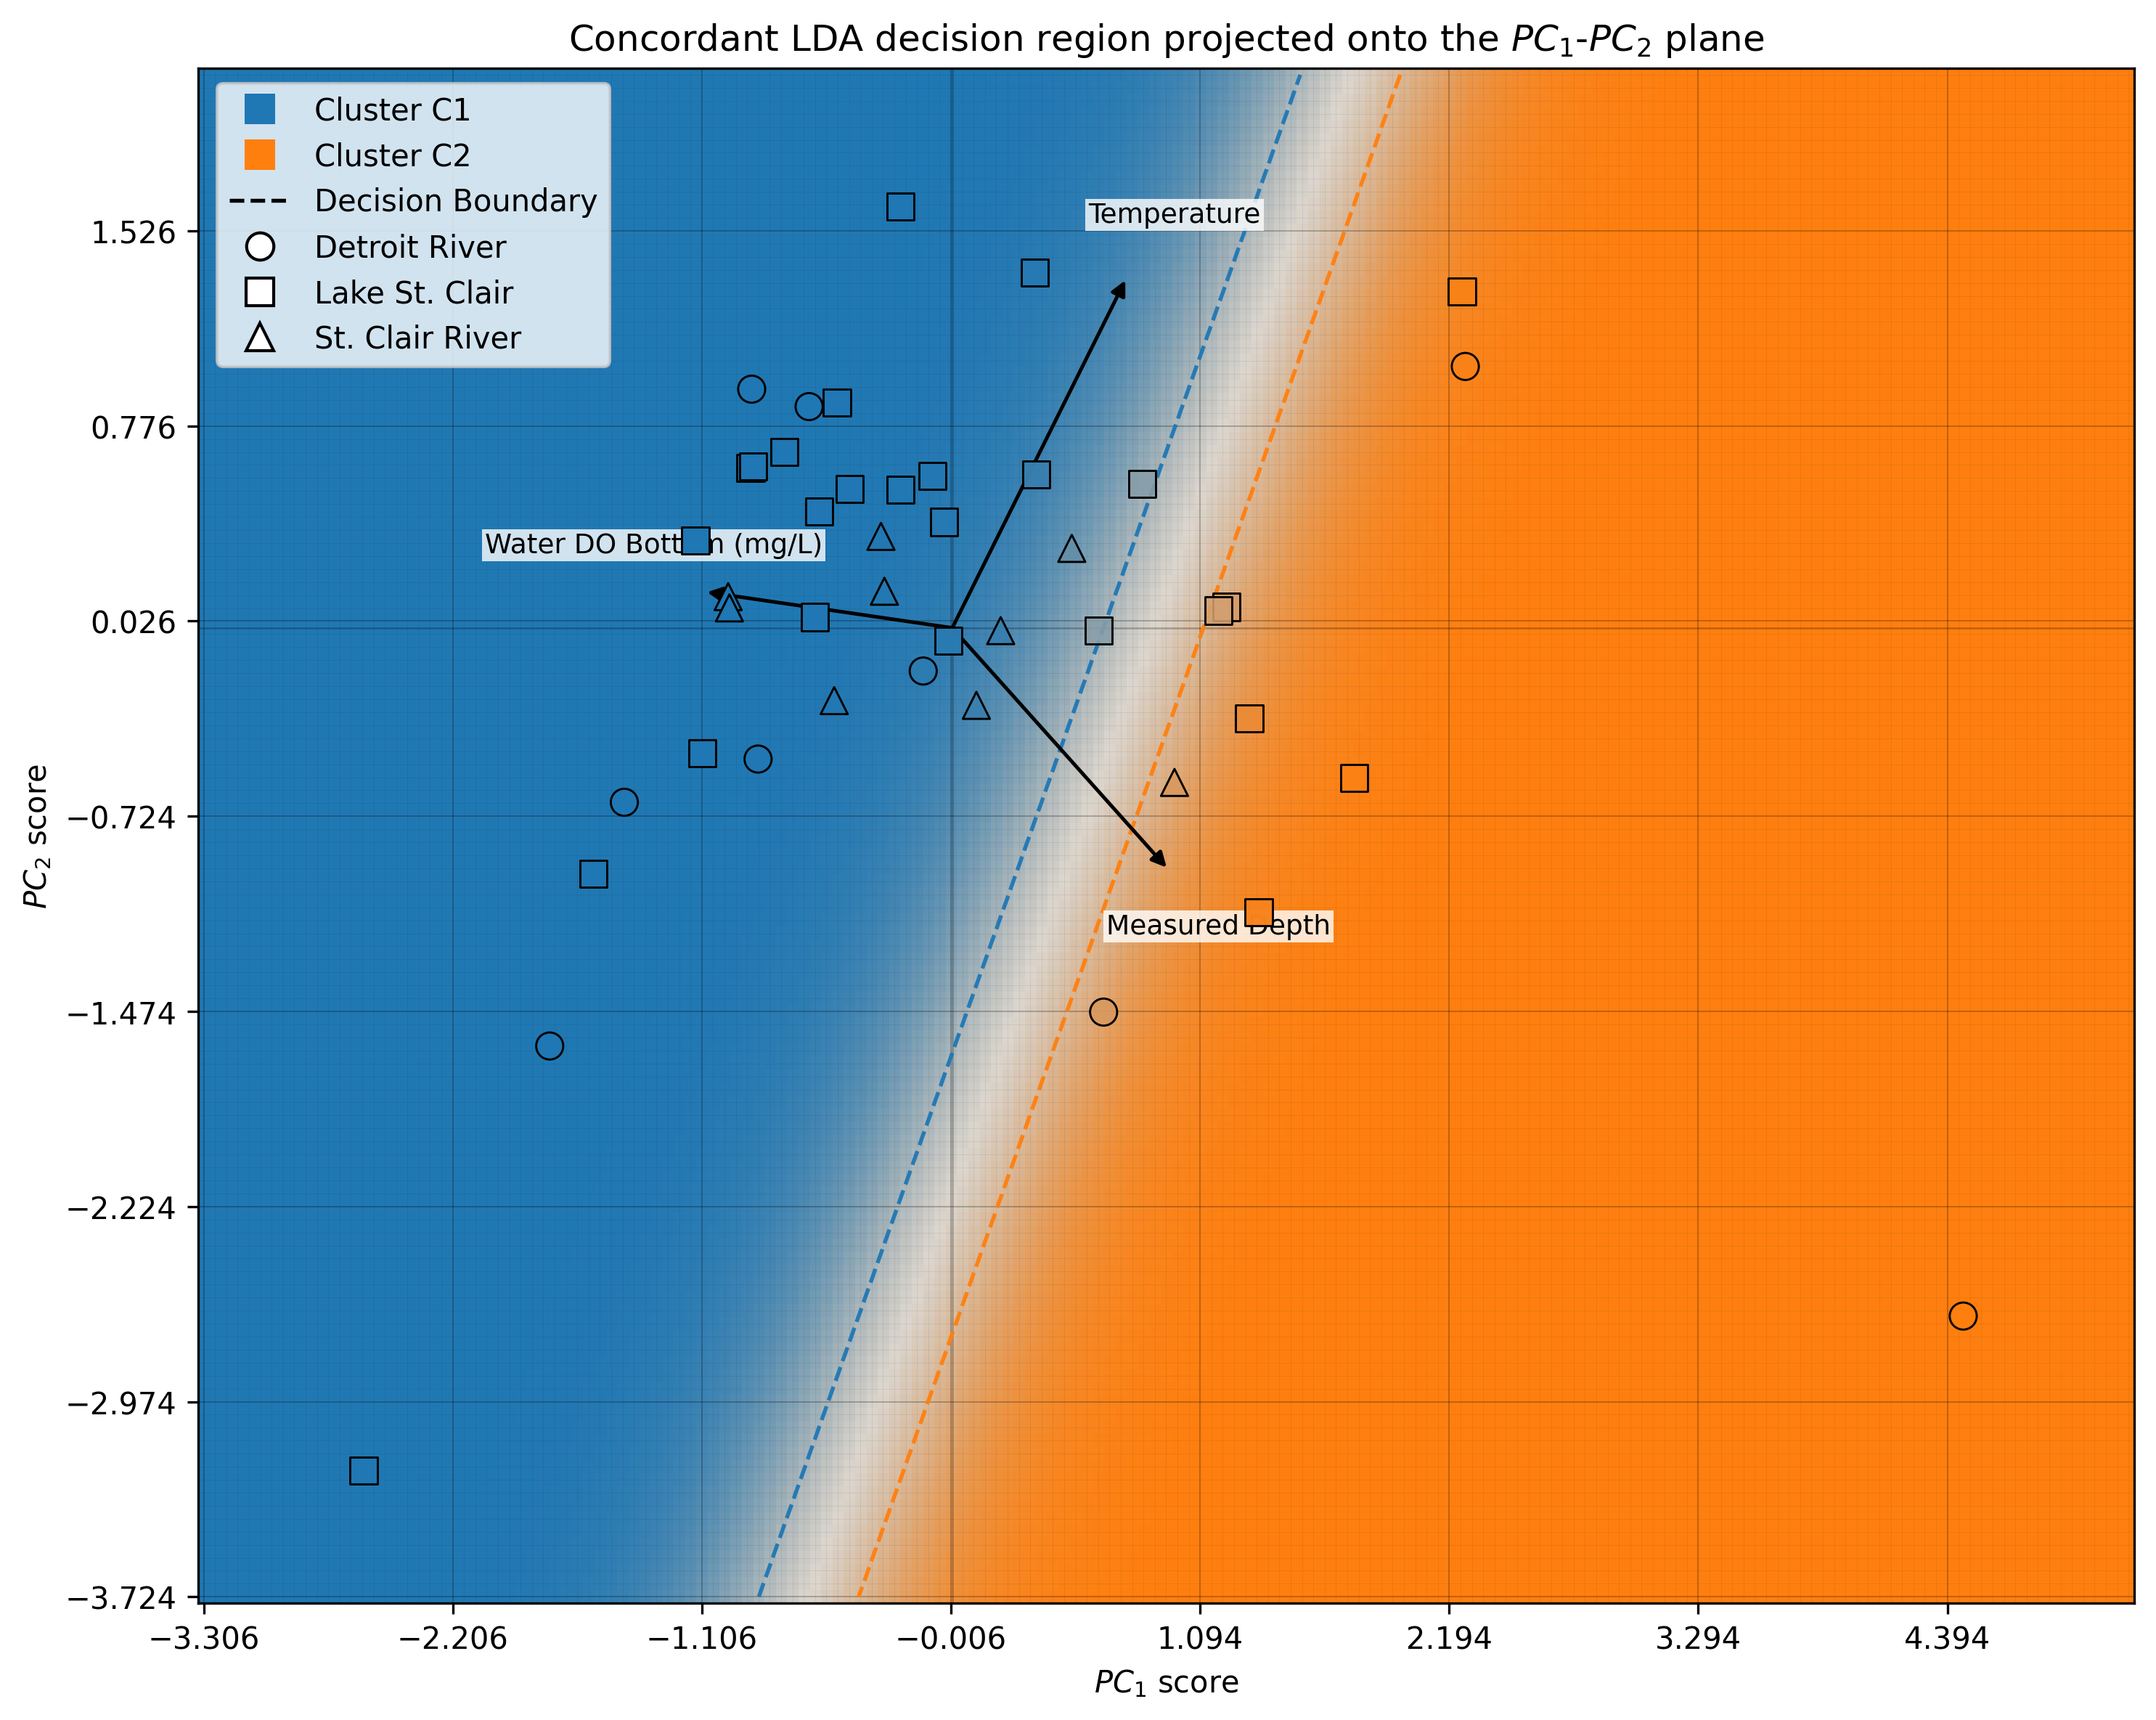

In [241]:
print("Concordant PCA decision-region heatmap with waterbody-shaped site overlays")
display(concordant_pca_region_figure)
# save the concordant pca decision-region heatmap into figures folder
concordant_pca_region_figure.savefig("../figures/ch3_fw3_concordant_pca_region_heatmap.png", dpi=300)

## Interpret the Env-Profile of 310 Sites into Cluster Memberships

In [242]:
all_site_site_projection_output_table = all_site_site_projection_table
all_site_cluster_c1_membership_output_table = all_site_cluster_C1_membership_table
all_site_cluster_c2_membership_output_table = all_site_cluster_C2_membership_table


print("All-site site projection table" + f"; Shape {all_site_site_projection_output_table.shape}")
display(all_site_site_projection_output_table.head())

print("All-site cluster C1 membership table" + f"; Shape {all_site_cluster_c1_membership_output_table.shape}")
display(all_site_cluster_c1_membership_output_table.head())
# save the all site cluster C1 membership projection table into artifacts folder
all_site_cluster_c1_membership_output_table.to_excel("../artifacts/A5_all_sites_cluster_C1.xlsx", index=False)

print("All-site cluster C2 membership table" + f"; Shape {all_site_cluster_c2_membership_output_table.shape}")
display(all_site_cluster_c2_membership_output_table.head())
# save the all site cluster C2 membership projection table into artifacts folder
all_site_cluster_c2_membership_output_table.to_excel("../artifacts/A6_all_sites_cluster_C2.xlsx", index=False)

All-site site projection table; Shape (310, 7)


,Integrated Code,PC1,PC2,decision boundary,cluster memberships,posterior probability: C1,posterior probability: C2
0,DR-02,-1.345982,-1.840818,0.7,"(1, 0)",0.801056,1.989437e-01
1,DR-03,-2.527524,-0.774774,0.7,"(1, 0)",0.999597,4.027536e-04
2,DR-04,-0.481962,0.414807,0.7,"(1, 0)",0.981485,1.851479e-02
3,DR-06,-0.467700,-2.356873,0.7,"(0, 1)",0.031551,9.684488e-01
4,DR-07,-5.006590,-0.403037,0.7,"(1, 0)",1.000000,8.557732e-08


All-site cluster C1 membership table; Shape (146, 3)


,Integrated Code,cluster membership,posterior probability
0,DR-02,C1,0.801056
1,DR-03,C1,0.999597
2,DR-04,C1,0.981485
3,DR-07,C1,1.000000
4,DR-08,C1,0.995683


All-site cluster C2 membership table; Shape (142, 3)


,Integrated Code,cluster membership,posterior probability
0,DR-06,C2,0.968449
1,DR-09,C2,0.728269
2,DR-10,C2,0.994261
3,DR-43,C2,0.999338
4,DR-54,C2,0.998802


All 310 sites projected onto the all-site PCA decision-region heatmap


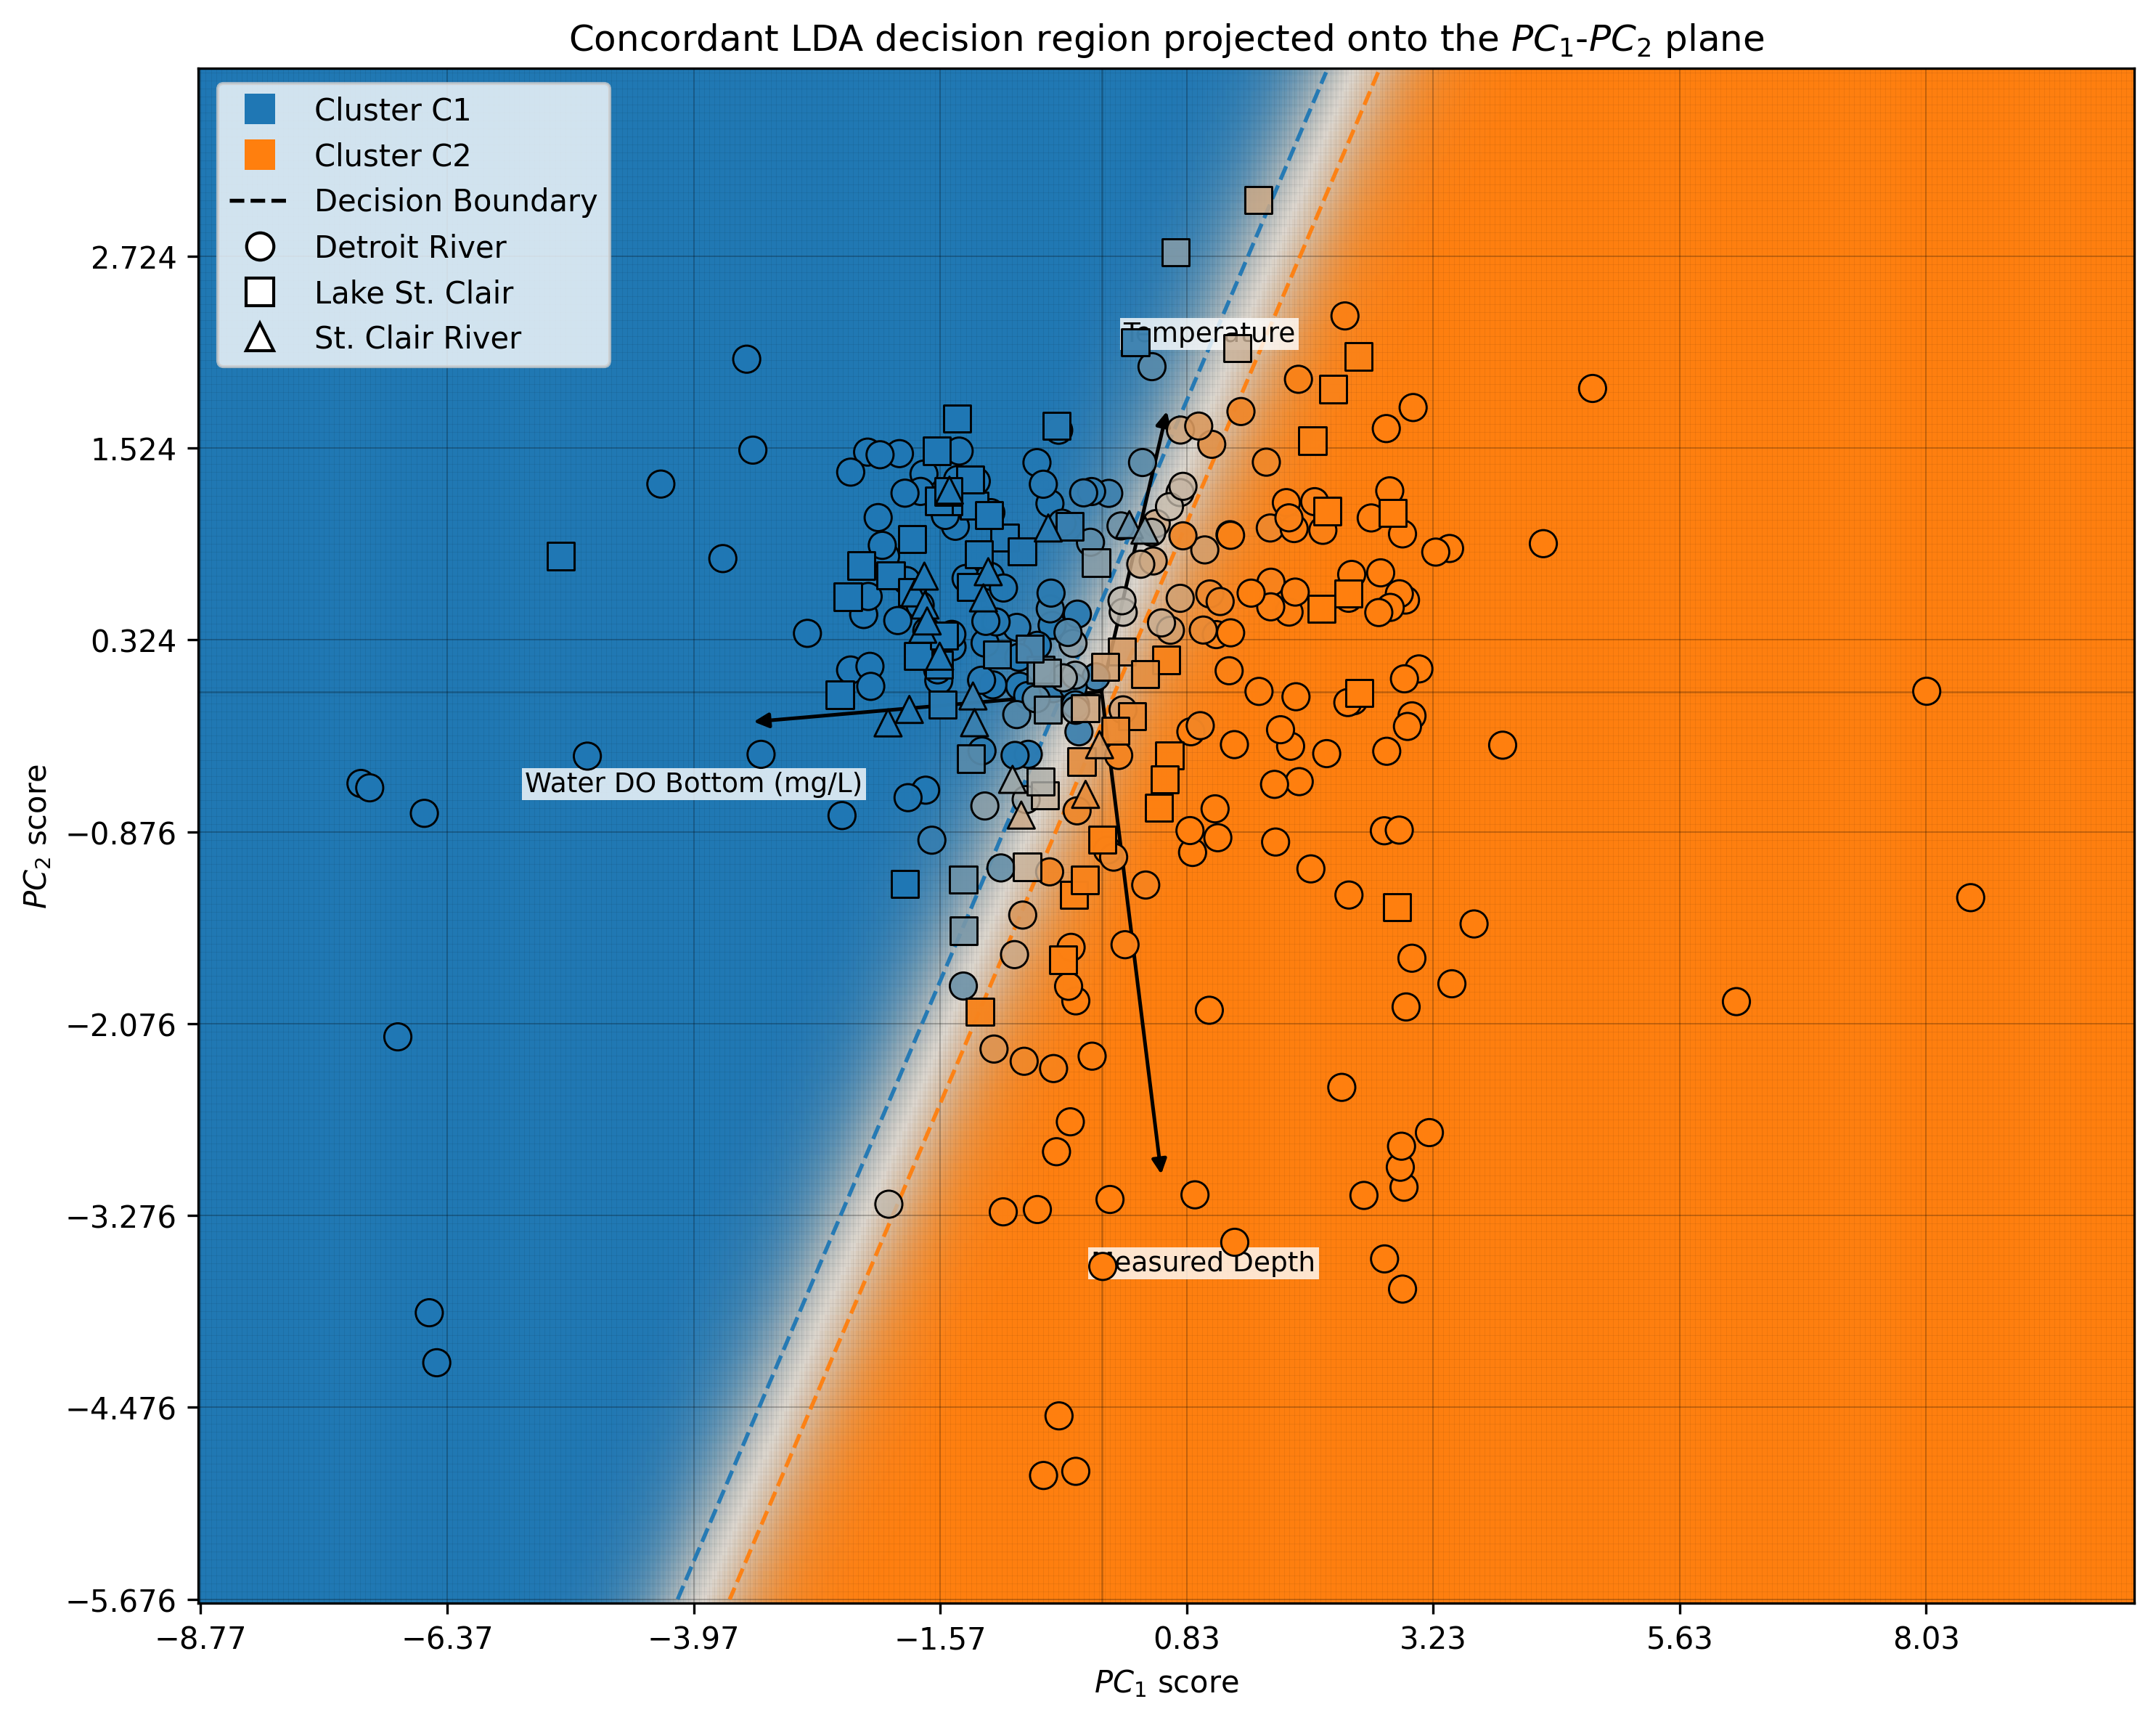

In [243]:
print("All 310 sites projected onto the all-site PCA decision-region heatmap")
display(all_site_pca_region_figure)
# save the all-site pca decision-region heatmap into figures folder
all_site_pca_region_figure.savefig("../figures/ch3_fw3_all_site_pca_region_heatmap.png", dpi=300)

### Other Supplementary Outputs (minor)

Other trivial tables, only check when need more supportive details

In [244]:
# concordant_training_labels_by_cluster_table = overview_output_tables["Concordant training labels by cluster"]
# benchmark_training_labels_by_cluster_table = overview_output_tables["Benchmark training labels by cluster"]
# diagnostic_component_overview_table = overview_output_tables["Status-derived feature and label datasets"]
# concordant_class_means_overview_table = overview_output_tables["Fitted concordant LDA class means"]
# benchmark_class_means_overview_table = overview_output_tables["Fitted benchmark LDA class means"]
# concordant_projection_summary_output_table = concordant_projection_summary_table
# concordant_explained_variance_ratio_output_table = concordant_explained_variance_ratio_table
# concordant_feature_loading_output_table = concordant_feature_loading_table
# concordant_held_constant_pc_scores_output_table = concordant_held_constant_pc_scores_table
# concordant_cluster_c1_membership_output_table = concordant_cluster_C1_membership_table
# concordant_cluster_c2_membership_output_table = concordant_cluster_C2_membership_table
# concordant_site_projection_output_table = concordant_site_projection_table
# all_site_projection_summary_output_table = all_site_projection_summary_table
# all_site_explained_variance_ratio_output_table = all_site_explained_variance_ratio_table
# all_site_feature_loading_output_table = all_site_feature_loading_table
# all_site_held_constant_pc_scores_output_table = all_site_held_constant_pc_scores_table
# all_site_grid_environmental_features_output_table = all_site_grid_environmental_features_table


# print("Concordant training labels by cluster")
# display(concordant_training_labels_by_cluster_table)
# print("Benchmark training labels by cluster")
# display(benchmark_training_labels_by_cluster_table)
# print("Status-derived feature and label datasets")
# display(diagnostic_component_overview_table)
# print("Fitted concordant LDA class means")
# display(concordant_class_means_overview_table)
# print("Fitted benchmark LDA class means")
# display(benchmark_class_means_overview_table)
# print("Concordant site projection table" + f"; Shape {concordant_site_projection_output_table.shape}")
# display(concordant_site_projection_output_table.head())
# print("Concordant PCA projection summary")
# display(concordant_projection_summary_output_table)
# print("Concordant explained variance ratio")
# display(concordant_explained_variance_ratio_output_table)
# print("Concordant feature loading table")
# display(concordant_feature_loading_output_table)
# print("Concordant held constant PC scores")
# display(concordant_held_constant_pc_scores_output_table)
# print("Concordant cluster C1 membership table" + f"; Shape {concordant_cluster_c1_membership_output_table.shape}")
# display(concordant_cluster_c1_membership_output_table.head())
# print("Concordant cluster C2 membership table" + f"; Shape {concordant_cluster_c2_membership_output_table.shape}")       
# display(concordant_cluster_c2_membership_output_table.head())
# print("All-site PCA projection summary")
# display(all_site_projection_summary_output_table)
# print("All-site explained variance ratio")
# display(all_site_explained_variance_ratio_output_table)
# print("All-site feature loading table")
# display(all_site_feature_loading_output_table)
# print("All-site held constant PC scores")
# display(all_site_held_constant_pc_scores_output_table)
# print("All-site grid environmental features")
# display(all_site_grid_environmental_features_output_table)


# Execution summary

After a complete run, this notebook should produce:

```text
../artifacts/A5_all_sites_cluster_projections.xlsx
../results/ch3_fw3_benchmark_lda_random_split_cv_confusion_matrix.xlsx
../results/ch3_fw3_benchmark_lda_stratified_confusion_matrix.xlsx
../results/ch3_fw3_concordant_lda_random_split_cv_confusion_matrix.xlsx
../results/ch3_fw3_concordant_lda_stratified_confusion_matrix.xlsx
../figures/ch3_fw3_all_site_pca_region_heatmap.png
../figures/ch3_fw3_concordant_pca_region_heatmap.png
```